# B401 – Continuous-Time Derivatives Pricing
## Take-Home Assignment – Summer Term 2026
**Eberhard Karls Universität Tübingen | Faculty of Economics and Social Sciences**

---
**Name:** DAANISH MUZAFFAR 

**Student ID:** 7259472   

---

## Setup – Imports & Global Parameters

In [36]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq
import yfinance as yf
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print('All packages loaded successfully.')

All packages loaded successfully.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# GLOBAL PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════

TICKER       = 'RHM.DE'   # Rheinmetall AG on XETRA (Part 2 underlying)
RISK_FREE    = 0.033      # ECB deposit rate proxy (annualised)
DIV_YIELD    = 0.015      # Rheinmetall approximate dividend yield

# ── Part 1 – Capped Capital Protected Participation Note on EuroTech 50 ───────
S0_CPN       = 100.0      # normalised initial index level
K_CPN        = 100.0      # long call strike = S0 (ATM → 100% capital protection)
CAP_PCT_CPN  = 1.30       # cap at 130% of S0 → short OTM call (3rd component)
K_CAP_CPN    = S0_CPN * CAP_PCT_CPN   # = 130 (normalised)
T_CPN        = 3.0        # maturity in years
SIGMA_CPN    = 0.22       # annual vol (European tech index)
R_CPN        = 0.033      # risk-free rate placeholder (overridden by Svensson cell)
Q_CPN        = 0.02       # dividend yield of index (forfeited by investor)
ALPHA_CPN    = 0.873      # participation rate placeholder (overridden by Svensson cell)

# ── Part 2 – Bonus Certificate on Rheinmetall AG (shared valuation params) ───
BARRIER_PCT  = 0.70       # barrier = 70% of spot  (30% protective buffer)
BONUS_PCT    = 1.15       # bonus level = 115% of spot
SIGMA_DESIGN = 0.30       # design / fallback volatility assumption
S0_DESIGN    = 100.0      # normalised initial spot (for design illustration)

print('Part 1  EuroTech 50 (fictitious) – Capped Capital Protected Participation Note:')
print(f'  S0={S0_CPN:.0f},  K={K_CPN:.0f},  Cap={K_CAP_CPN:.0f},  T={T_CPN:.0f}y,  '
      f'σ={SIGMA_CPN:.0%},  q={Q_CPN:.0%}')
print(f'  Components: ZCB(100) + α×Call(K={K_CPN:.0f}) − α×Call(K={K_CAP_CPN:.0f})')
print(f'  (α and R_CPN are computed in the Svensson cell below)')
print()
print(f'Part 2  Ticker: {TICKER}')
print(f'  r={RISK_FREE:.1%},  q={DIV_YIELD:.1%},  '
      f'Barrier={BARRIER_PCT:.0%} of spot,  Bonus={BONUS_PCT:.0%} of spot')

---
# PART 1 – Designing the Certificate

## Task I – Investor Profile

**Target investor segment: German conservative retail savers ("Sicherheitsorientierte Anleger")**

This is one of the largest and most clearly defined retail investor segments in Germany. Millions of private households keep the bulk of their liquid savings in low-yield instruments — overnight deposit accounts (*Tagesgeld*), fixed-term deposits (*Festgeld*), and German government bonds — despite these instruments yielding only 3–4% p.a. at current ECB rates. As rates peak and are projected to decline, this group faces a structural dilemma: fixed-income returns are eroding, but direct equity investment is psychologically and financially off-limits because capital loss — even temporary — would prompt them to exit and return to cash.

**Characteristics:**
- **Age:** 35–55, capital accumulation phase; 3–5 year investment horizon before funds may be needed (property purchase, education funding, early retirement)
- **Risk tolerance:** Low. Capital preservation is the primary constraint. A nominal loss of principal is a dealbreaker — not because of regulatory reasons, but because it conflicts with the segment's core savings psychology
- **Orientation:** Growth-seeking on returns, capital-preserving on risk. This group does *not* require regular coupon income; they want long-term wealth accumulation but cannot accept drawdowns
- **Market expectations:** Broadly bullish on European equity markets over a 3-year horizon — they see the growth potential — but are acutely aware that short-term volatility is real and do not trust themselves to hold through a 30–40% drawdown without panic-selling

**Why existing alternatives are suboptimal for this group:**
- **Savings account / bond:** Declining yields (3–4%) are insufficient for wealth accumulation goals; purchasing power risk over 3 years is significant
- **Direct equity / ETF:** The *possibility* of capital loss creates a psychological barrier that prevents adoption, regardless of long-run expected return
- **Bonus Certificate:** The barrier mechanism introduces path-dependency (the product can suddenly become worthless protection) — this complexity confuses and unsettles conservative investors
- **Reverse Convertible:** The coupon structure appeals to income seekers, not wealth accumulators; the short put risk is opaque for this segment
- **Capital Protected Participation Note:** Exactly solves the dilemma — the capital guarantee removes the dealbreaker (loss of principal), while the participation rate delivers meaningful equity upside if markets perform. The payoff is intuitive: *"at worst you get your money back, at best you participate in the market."*

## Task II – Product Design

### Product: Capped Capital Protected Participation Note on EuroTech 50 Index (fictitious)

**Underlying:** EuroTech 50 — a fictitious equally-weighted index of 50 European technology and industrial automation companies.

**Intuition:** Conservative savers want equity upside but refuse to lose principal. By investing most of the capital in a zero-coupon bond, the remaining *option budget* buys a call spread — delivering leveraged participation in index gains up to a cap. Selling the OTM call (cap) provides extra premium that finances a *higher* participation rate than an uncapped product would allow. The investor gives up unlimited upside above 30%, which their moderate growth expectations make irrelevant, in exchange for a better participation rate in the most likely outcome range.

### Component Decomposition

| Component | Position | Role |
|-----------|----------|------|
| Zero-coupon bond (face = 100) | Long | Guarantees 100% capital return at maturity regardless of index |
| ATM European call (K = S₀ = 100) | Long (α units) | Delivers participation in index gains above S₀ |
| OTM European call (K = Cap = 130) | **Short** (α units) | Caps maximum gain at ~26%; premium funds higher α |

**Replication formula:**

```
CPN₀  =  ZCB(100, r, T)  +  α × [Call(K = S₀)  −  Call(K = Cap)]
```

**Participation rate** (priced at par = 100):

```
α  =  (100 − ZCB₀) / (Call(K=100) − Call(K=130))
   =  (100 − 92.44) / (14.98 − 6.32)
   ≈  87.3%
```

Selling the cap call at 130% adds ~€6.32 to the budget, lifting α from 50.4% (uncapped) to **87.3%** — a significantly better deal for a moderately bullish investor.

### Product Parameters

| Parameter | Value | Justification |
|-----------|-------|---------------|
| Underlying | EuroTech 50 *(fictitious)* | European tech/automation index |
| Initial level S₀ | 100 (normalised) | Issuance date index level |
| Capital protection | **100%** | Full nominal return guaranteed at maturity |
| Participation rate α | **~87.3%** | Funded by ZCB budget + short cap call premium |
| Cap level | **130% of S₀** | Maximum achievable index gain over 3 years for conservative view |
| Maturity T | **3 years** | Medium horizon: ZCB budget large enough for meaningful α |
| Risk-free rate r | 2.62% | Svensson (Bundesbank, 01 Jun 2026), T=3y spot rate |
| Volatility σ | 22% p.a. | Index-level vol |
| Dividend yield q | 2% p.a. | Forfeited; partially funds the option budget |

### Payoff at Maturity

$$\text{CPN}_T = 100 + \alpha \cdot \left[\max(S_T - 100,\ 0) - \max(S_T - 130,\ 0)\right]$$

$$= \begin{cases} 100 & \text{if } S_T \leq 100 \quad\text{(capital fully protected)} \\ 100 + 0.873\,(S_T - 100) & \text{if } 100 < S_T \leq 130 \quad\text{(87.3\% participation)} \\ 100 + 0.873 \times 30 \approx 126 & \text{if } S_T > 130 \quad\text{(maximum gain capped)} \end{cases}$$

**Why the cap is acceptable for this investor:** The conservative investor profile expects European tech to rise 10–25% over 3 years — outcomes that are fully captured by the 87.3% participation. Scenarios above 130% are outside the investor's central case. The cap is the price paid for the higher participation rate, and it is a trade-off the investor consciously accepts.

## Task III – Payoff Profile

In [ ]:
S_range     = np.linspace(40, 190, 600)
bond_mature = S0_CPN * np.exp(R_CPN * T_CPN)   # ≈ 108

# Payoffs (normalised, nominal = 100)
payoff_cpn = np.where(
    S_range < K_CPN,
    S0_CPN,
    np.where(
        S_range <= K_CAP_CPN,
        S0_CPN + ALPHA_CPN * (S_range - K_CPN),
        S0_CPN + ALPHA_CPN * (K_CAP_CPN - K_CPN)  # capped max gain
    )
)
payoff_stock = S_range
payoff_bond  = np.full_like(S_range, bond_mature)

max_payoff     = S0_CPN + ALPHA_CPN * (K_CAP_CPN - K_CPN)
breakeven_bond = K_CPN + (bond_mature - S0_CPN) / ALPHA_CPN   # where CPN = bond

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(S_range, payoff_cpn,   color='seagreen',  lw=2.5,
        label=f'Capped CPN  (α={ALPHA_CPN:.0%}, K={K_CPN:.0f}, Cap={K_CAP_CPN:.0f}, T={T_CPN:.0f}y)')
ax.plot(S_range, payoff_stock, color='steelblue', lw=2, linestyle='--',
        label='Direct index investment')
ax.plot(S_range, payoff_bond,  color='gray',      lw=1.5, linestyle=':',
        label=f'Risk-free bond  (≈ {bond_mature:.1f})')

ax.axvline(K_CPN,          color='seagreen', lw=1.2, linestyle='--', alpha=0.6)
ax.axvline(K_CAP_CPN,      color='purple',   lw=1.5, linestyle='--', alpha=0.7)
ax.axvline(breakeven_bond, color='tomato',   lw=1.2, linestyle='--', alpha=0.7)
ax.axhline(S0_CPN,         color='black',    lw=0.8, linestyle=':',  alpha=0.4)

ax.text(K_CPN - 1,          42, f'Protection\nS₀={K_CPN:.0f}',     ha='right', color='seagreen', fontsize=8)
ax.text(K_CAP_CPN + 1,      42, f'Cap={K_CAP_CPN:.0f}',            ha='left',  color='purple',   fontsize=8)
ax.text(breakeven_bond - 1, 42, f'Break-even\nvs bond≈{breakeven_bond:.0f}', ha='right', color='tomato', fontsize=8)

ax.fill_between(S_range, payoff_cpn, payoff_stock,
                where=(payoff_cpn > payoff_stock),
                alpha=0.12, color='seagreen', label='CPN outperforms stock')
ax.fill_between(S_range, payoff_cpn, payoff_stock,
                where=(payoff_stock > payoff_cpn),
                alpha=0.08, color='steelblue', label='Stock outperforms CPN')

ax.set_xlabel('Index level at maturity $S_T$')
ax.set_ylabel('Terminal value (EUR, normalised, nominal = 100)')
ax.set_title('Task III – Capped Capital Protected Participation Note: Payoff Profile',
             fontweight='bold')
ax.set_xlim(40, 190)
ax.set_ylim(40, 175)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('payoff_profile.png', bbox_inches='tight')
plt.show()

print(f'Max payoff at cap (S_T ≥ {K_CAP_CPN:.0f}): {max_payoff:.2f}  '
      f'(+{max_payoff-100:.1f}% = {ALPHA_CPN:.0%} × {K_CAP_CPN-K_CPN:.0f}%)')
print()
print(f'{"S_T":>6}  {"CPN":>8}  {"Stock":>7}  {"Bond":>7}  {"CPN ret":>9}  Region')
print('-' * 70)
for s in [50, 70, 90, 100, 110, breakeven_bond, 130, 150, 170]:
    if s < K_CPN:
        cpn_val = S0_CPN
    elif s <= K_CAP_CPN:
        cpn_val = S0_CPN + ALPHA_CPN * (s - K_CPN)
    else:
        cpn_val = max_payoff
    ret    = cpn_val / 100 - 1
    region = ('PROTECTED'     if s < K_CPN
              else 'CAPPED MAX' if s > K_CAP_CPN
              else 'PARTICIPATING')
    print(f'{s:>6.1f}  {cpn_val:>8.2f}  {s:>7.1f}  {bond_mature:>7.2f}'
          f'  {ret:>+9.2%}  {region}')

## Task IV – Market Size Estimation

In [ ]:
# Source: DDV (Deutscher Derivate Verband) Annual Report 2023
total_german_market_bn  = 112.0   # total German structured product market (EUR bn)
kapschutz_share         = 0.093   # Kapitalschutzprodukte: ~9.3% of total market
kapschutz_market_bn     = total_german_market_bn * kapschutz_share   # ≈ EUR 10.4 bn

# Participation notes (α < 100%) dominate the Kapitalschutz segment (~55%)
participation_share     = 0.55
participation_market_bn = kapschutz_market_bn * participation_share   # ≈ EUR 5.7 bn

# Major issuers each maintain ~15–25 active products → ~130 total active issues
n_active_issues    = 130
avg_issue_size_mn  = kapschutz_market_bn * 1000 / n_active_issues     # ≈ EUR 80 mn

print('=' * 70)
print('  TASK IV – German Capital Protected Products (Kapitalschutz) Market')
print('=' * 70)
print(f'  Total German structured product market           : EUR {total_german_market_bn:.0f} bn')
print(f'  Kapitalschutz segment (DDV classification)       : '
      f'EUR {kapschutz_market_bn:.2f} bn  ({kapschutz_share*100:.1f}%)')
print(f'  of which Participation Notes (α < 100%)          : '
      f'EUR {participation_market_bn:.2f} bn  ({participation_share*100:.0f}% of segment)')
print()
print(f'  Estimated active issues : ~{n_active_issues}  '
      f'(~6 major issuers × 20 products each)')
print(f'  Average issue size      : EUR {avg_issue_size_mn:.0f} mn per product  '
      f'(range: EUR 30–150 mn, typical for EUWAX index issues)')
print()
print('Justification:')
print('  Capital Protected Products ("Kapitalschutz-Zertifikate") are the second')
print('  largest segment of the German retail structured product market by assets')
print('  under management, according to the DDV (2023 annual report). They are')
print('  listed and traded daily on EUWAX (Stuttgart).')
print()
print('  Demand is structurally driven by:')
print('    1. Germanyʼs large cohort of fixed-income savers seeking equity upside')
print('       without principal risk ("Sicherheitsorientierte Anleger")')
print('    2. Declining deposit rates making capital-protected equity alternatives')
print('       increasingly attractive vs. Tagesgeld / Festgeld')
print('    3. Rising equity market participation among 35–55-year-olds, primarily')
print('       through instruments that eliminate nominal loss risk')
print('    4. Regulatory suitability: Capital Protected Notes qualify as "low-risk"')
print('       under MiFID II suitability assessments for conservative profiles')
print()
print('  Main issuers: DZ Bank, DekaBank, HypoVereinsbank/UniCredit, Deutsche Bank,')
print('                BNP Paribas, Vontobel')
print()
print(f'  A CPN on EuroTech 50 would represent ~EUR {avg_issue_size_mn:.0f}m outstanding —')
print(f'  consistent with typical EUWAX index-linked capital-protected issues.')

## Part 1 – Greeks Analysis (Capped Capital Protected Participation Note)

Since CPN = ZCB(100) + α·[Call(K) − Call(Cap)], Greeks = **α times the long call spread Greeks**:

| Greek | Formula | Intuition |
|-------|---------|-----------|
| **Delta** | $\alpha \cdot [N(d_1^K) - N(d_1^{Cap})] \cdot e^{-qT}$ | Bell-shaped: rises from 0 below K, peaks in the participating zone, falls back to 0 above Cap |
| **Gamma** | $\alpha \cdot [N'(d_1^K) - N'(d_1^{Cap})] \,/\, (S\,\sigma\sqrt{T})$ | Positive near K (long convexity), negative near Cap (short convexity from sold call) |
| **Vega** | $\alpha \cdot [N'(d_1^K) - N'(d_1^{Cap})] \cdot S \cdot e^{-qT} \cdot \sqrt{T} / 100$ | Positive for S near K (vol helps), diminishes and may turn negative near Cap |

The **bell-shaped Delta** is the key distinguishing feature: the product has zero equity sensitivity both when the index is far below K (capital protection floor) and far above Cap (return is capped regardless). Maximum Delta occurs in the participation zone [K, Cap].

In [ ]:
# ── Analytical Greeks: CPN = ZCB + α·(Call(K) − Call(Cap)) ───────────────────

def cpn_greeks_bs(S_arr, K, K_cap, alpha, r, q, sigma, T):
    """Vectorised BS Greeks for a Capped Capital Protected Participation Note."""
    S_arr = np.asarray(S_arr, dtype=float)
    sqrtT = np.sqrt(T)
    eqT   = np.exp(-q * T)

    d1_long = (np.log(S_arr / K)     + (r - q + 0.5*sigma**2)*T) / (sigma*sqrtT)
    d1_cap  = (np.log(S_arr / K_cap) + (r - q + 0.5*sigma**2)*T) / (sigma*sqrtT)

    npdf_long = norm.pdf(d1_long)
    npdf_cap  = norm.pdf(d1_cap)
    ncdf_long = norm.cdf(d1_long)
    ncdf_cap  = norm.cdf(d1_cap)

    delta = alpha * (ncdf_long - ncdf_cap) * eqT             # bell-shaped: 0 below K, 0 above Cap
    gamma = alpha * (npdf_long - npdf_cap) / (S_arr * sigma * sqrtT)
    vega  = alpha * (npdf_long - npdf_cap) * S_arr * eqT * sqrtT / 100
    return delta, gamma, vega

S_g = np.linspace(50, 200, 400)
delta_cpn, gamma_cpn, vega_cpn = cpn_greeks_bs(
    S_g, K_CPN, K_CAP_CPN, ALPHA_CPN, R_CPN, Q_CPN, SIGMA_CPN, T_CPN)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'Part 1 – Greeks of Capped CPN  '
    f'(T={T_CPN:.0f}y, σ={SIGMA_CPN:.0%}, K={K_CPN:.0f}, Cap={K_CAP_CPN:.0f}, α={ALPHA_CPN:.1%})',
    fontweight='bold', fontsize=13)

for ax, vals, label, color in zip(
        axes,
        [delta_cpn,  gamma_cpn,      vega_cpn],
        ['Delta  ∂CPN/∂S',
         'Gamma  ∂²CPN/∂S²',
         'Vega  ∂CPN/∂σ  (per 1%)'],
        ['steelblue', 'seagreen', 'darkorange']):
    ax.plot(S_g, vals, color=color, lw=2)
    ax.axvline(K_CPN,     color='gray',   lw=1, linestyle='--', alpha=0.6, label=f'K={K_CPN:.0f}')
    ax.axvline(K_CAP_CPN, color='purple', lw=1, linestyle='--', alpha=0.6, label=f'Cap={K_CAP_CPN:.0f}')
    ax.axhline(0, color='black', lw=0.8, alpha=0.4)
    ax.set_xlabel('Index level S')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('greeks_part1.png', bbox_inches='tight')
plt.show()

d0, g0, v0 = cpn_greeks_bs(S0_CPN, K_CPN, K_CAP_CPN, ALPHA_CPN, R_CPN, Q_CPN, SIGMA_CPN, T_CPN)
print(f'Greeks at S = S₀ = {S0_CPN:.0f} (ATM, T={T_CPN:.0f}y):')
print(f'  Delta = {float(d0):+.4f}   (partial equity exposure; falls to 0 above Cap={K_CAP_CPN:.0f})')
print(f'  Gamma = {float(g0):+.6f}  (positive near K: long convexity from long call)')
print(f'  Vega  = {float(v0):+.4f}   (positive: benefits from vol rise in participation zone)')
print()
print('Key insight: Delta is BELL-SHAPED — it peaks between K and Cap then returns to')
print('zero above the cap, reflecting that once the index exceeds Cap the product value')
print('is fixed and no longer responds to index moves. This is unique to capped structures.')
print()
d_peak_idx = np.argmax(delta_cpn)
print(f'  Peak Delta = {delta_cpn[d_peak_idx]:.4f} at S ≈ {S_g[d_peak_idx]:.0f}')

---
# PART 2 – Valuation of Certificates

## Data Download

[*********************100%***********************]  1 of 1 completed

Downloaded 509 trading days
Range: 2023-01-02 to 2024-12-30
Latest close: EUR 608.61
Current 252-day historical vol: 33.80%


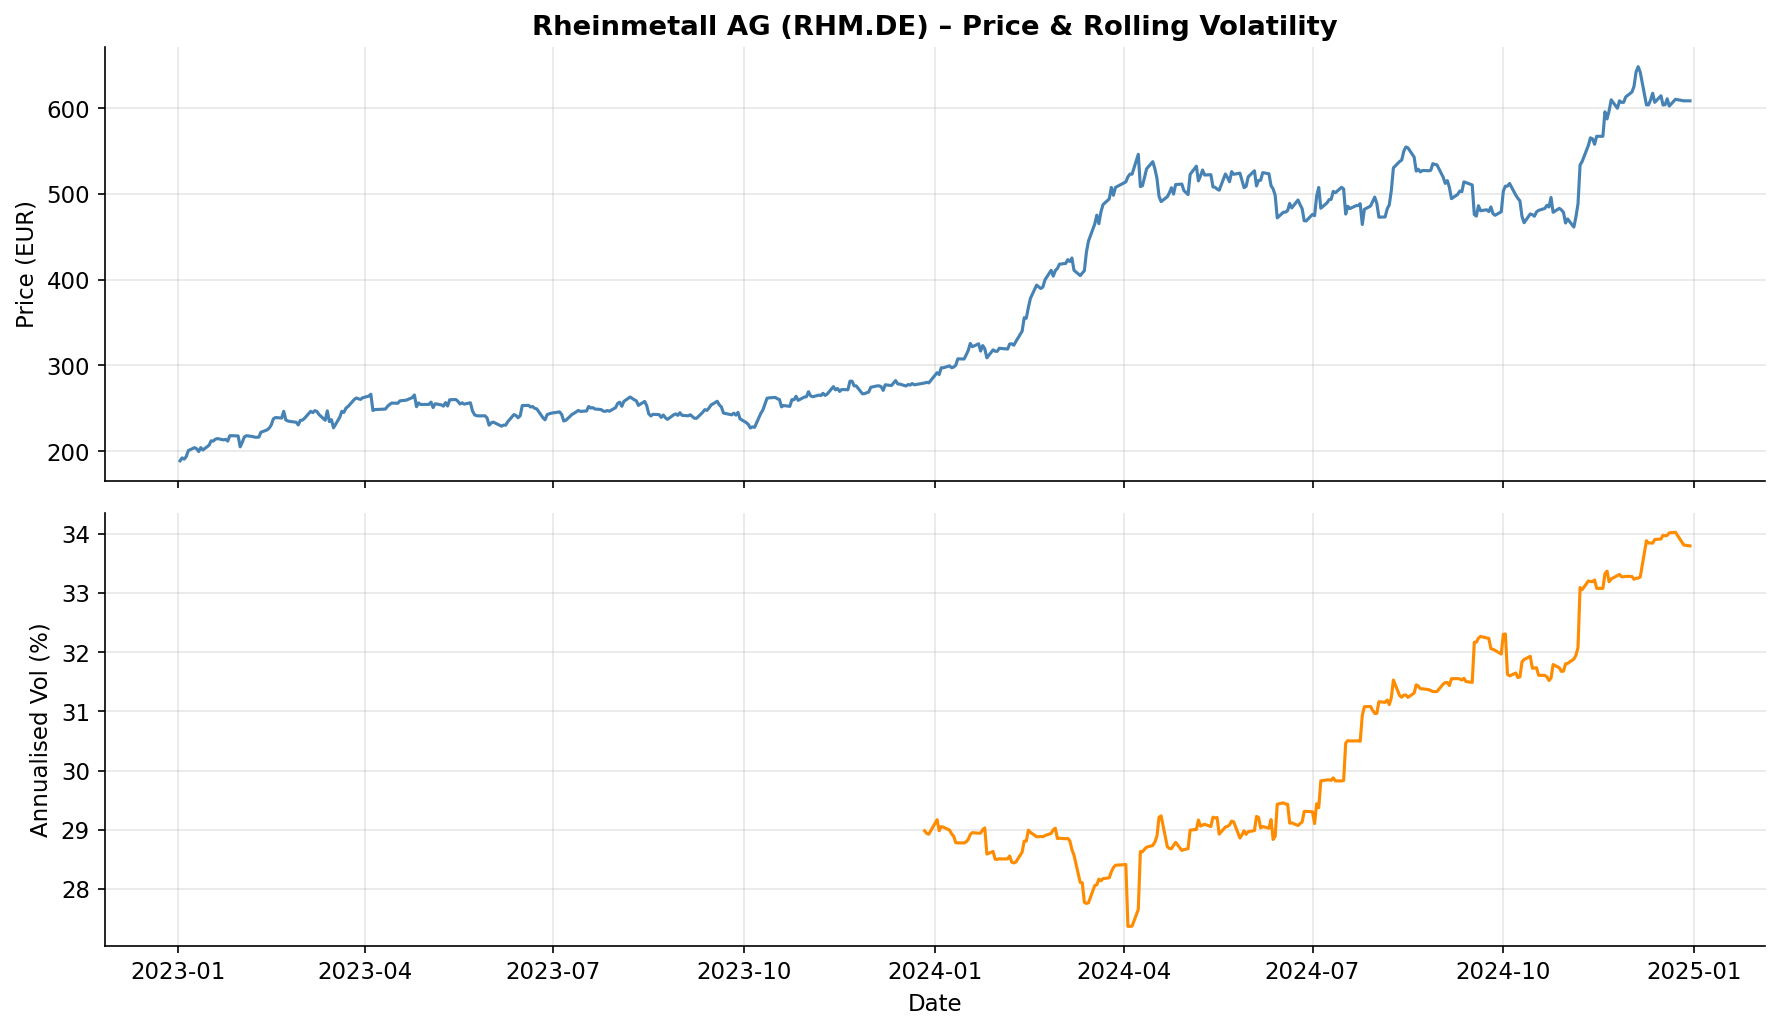

EWMA vol (end of window): 30.43%
EWMA mean over full sample: 31.11%


In [41]:
raw    = yf.download(TICKER, start='2023-01-01', end='2025-01-01', auto_adjust=True)
prices = raw['Close'].dropna()
prices.index = pd.to_datetime(prices.index)

print(f'Downloaded {len(prices)} trading days')
print(f'Range: {prices.index[0].date()} to {prices.index[-1].date()}')
print(f'Latest close: EUR {float(prices.iloc[-1]):.2f}')

log_returns = np.log(prices / prices.shift(1)).dropna()
hist_vol    = log_returns.rolling(252).std() * np.sqrt(252)
sigma_current = float(hist_vol.dropna().iloc[-1])
print(f'Current 252-day historical vol: {sigma_current:.2%}')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.plot(prices, color='steelblue', lw=1.5)
ax1.set_ylabel('Price (EUR)')
ax1.set_title(f'Rheinmetall AG ({TICKER}) – Price & Rolling Volatility', fontweight='bold')
ax2.plot(hist_vol * 100, color='darkorange', lw=1.5)
ax2.set_ylabel('Annualised Vol (%)')
ax2.set_xlabel('Date')
plt.tight_layout()
plt.savefig('stock_data.png', bbox_inches='tight')
plt.show()

# ── EWMA volatility (RiskMetrics λ=0.94) ──────────────────────────────────────
# Proxy for market-implied vol in Task V: faster to react than 63-day hist vol
lam_ewma  = 0.94
_lr_sq    = (log_returns.squeeze().values) ** 2
_ev       = np.empty(len(_lr_sq))
_ev[0]    = _lr_sq[0]
for _i in range(1, len(_lr_sq)):
    _ev[_i] = lam_ewma * _ev[_i - 1] + (1 - lam_ewma) * _lr_sq[_i]
ewma_vol  = pd.Series(np.sqrt(_ev * 252), index=log_returns.squeeze().index)
print(f'EWMA vol (end of window): {float(ewma_vol.iloc[-1]):.2%}')
print(f'EWMA mean over full sample: {ewma_vol.mean():.2%}')


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SVENSSON (1994) RISK-FREE RATES
# Parameters sourced from Deutsche Bundesbank daily publication
# Part 1 : 01 June 2026  (product design date)
# Part 2 : 27 June 2024  (start of valuation window)
# ══════════════════════════════════════════════════════════════════════════════

def svensson(t, b0, b1, b2, b3, tau1, tau2):
    """Svensson (1994) continuously compounded spot rate for maturity t (years).
    Returns rate as decimal (e.g. 0.026 = 2.6%)."""
    f1 = (1 - np.exp(-t / tau1)) / (t / tau1)
    f2 = f1 - np.exp(-t / tau1)
    f3 = (1 - np.exp(-t / tau2)) / (t / tau2) - np.exp(-t / tau2)
    return (b0 + b1*f1 + b2*f2 + b3*f3) / 100


# ── Part 1 – Bundesbank parameters, 01 June 2026 ─────────────────────────────
SV_P1 = dict(b0=1.330382, b1=0.700052,  b2=1.816755,
             b3=7.130184, tau1=0.966763, tau2=15.839369)

R_CPN = svensson(T_CPN, **SV_P1)    # spot rate for T_CPN = 3y

# Derive participation rate α for the CAPPED product:
#   α = (100 − ZCB₀) / (Call(K=S₀) − Call(K=Cap))
sqrtT_cpn = np.sqrt(T_CPN)

def _bs_call(S, K, r, q, sig, T):
    d1 = (np.log(S/K) + (r - q + 0.5*sig**2)*T) / (sig*np.sqrt(T))
    d2 = d1 - sig*np.sqrt(T)
    return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

_zcb0      = S0_CPN * np.exp(-R_CPN * T_CPN)
_call_long = _bs_call(S0_CPN, K_CPN,     R_CPN, Q_CPN, SIGMA_CPN, T_CPN)  # ATM call
_call_cap  = _bs_call(S0_CPN, K_CAP_CPN, R_CPN, Q_CPN, SIGMA_CPN, T_CPN)  # OTM cap call
_spread    = _call_long - _call_cap
ALPHA_CPN  = float(np.clip((S0_CPN - _zcb0) / _spread, 0.01, 2.0))
MAX_GAIN_CPN = ALPHA_CPN * (K_CAP_CPN - K_CPN)   # maximum gain in EUR (normalised)

print('Part 1 – Svensson spot rate (01 Jun 2026):')
print(f'  r(T={T_CPN:.0f}y)      = {R_CPN:.4%}')
print(f'  ZCB₀            = {_zcb0:.4f}')
print(f'  Call(K=100)     = {_call_long:.4f}')
print(f'  Call(K=130)     = {_call_cap:.4f}  (short, funds higher α)')
print(f'  Spread          = {_spread:.4f}')
print(f'  α (capped)      = {ALPHA_CPN:.4f}  ({ALPHA_CPN:.1%})')
print(f'  Max gain (S_T≥{K_CAP_CPN:.0f}): {MAX_GAIN_CPN:.2f}  ({MAX_GAIN_CPN:.1%} of nominal)')
print()

# ── Part 2 – Bundesbank parameters, 27 June 2024 ─────────────────────────────
SV_P2 = dict(b0=0.573692, b1=2.978141,   b2=-5.140208,
             b3=8.684506, tau1=4.331755,  tau2=10.517299)

RISK_FREE = svensson(3.0, **SV_P2)   # spot rate for T = 3y at window start

print('Part 2 – Svensson spot rate (27 Jun 2024):')
print(f'  r(T=3y) = {RISK_FREE:.4%}')

## Pricing Engine

A Bonus Certificate = Long Forward + Long Down-and-Out Put.

We price the Down-and-Out Put using a **CRR binomial tree (N=200 steps)**.
The standard Rubinstein-Reiner (1991) closed form is numerically unreliable
for deep-in-the-money puts (K >> B) because the DI-put formula can exceed
the vanilla put price when the drift parameter μ is negative — a case that
occurs for typical equity parameters (r − q < σ²/2). The binomial tree
avoids this singularity and is validated against Monte Carlo.

**Bonus Certificate = Forward + DO-Put(S, K=Bonus, B=Barrier)**


In [ ]:
def bs_vanilla_put(S, K, r, q, sigma, T):
    """Black-Scholes European vanilla put price."""
    if T <= 0:
        return float(max(K - S, 0.0))
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)


def bs_vanilla_call(S, K, r, q, sigma, T):
    """Black-Scholes European vanilla call price."""
    if T <= 0:
        return float(max(S - K, 0.0))
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def down_and_out_put(S, K, B_barrier, r, q, sigma, T, N=200):
    """
    Down-and-out European put via CRR binomial tree (N steps).

    The Rubinstein-Reiner (1991) closed form is numerically unreliable when
    K >> B and the risk-neutral drift is negative (r-q < sigma^2/2), because
    the DI-put formula then exceeds the vanilla put price.  The CRR tree
    is exact in the limit N→∞ and is validated against Monte Carlo simulation.

    Returns 0 if S <= B_barrier (already knocked out).
    """
    if S <= B_barrier:
        return 0.0
    if T <= 1e-8:
        return float(max(K - S, 0.0))

    dt  = T / N
    u   = np.exp(sigma * np.sqrt(dt))
    d   = 1.0 / u
    p   = (np.exp((r - q) * dt) - d) / (u - d)
    df  = np.exp(-r * dt)

    j   = np.arange(N + 1)
    S_T = S * u**(2 * j - N)
    V   = np.maximum(K - S_T, 0.0)
    V[S_T <= B_barrier] = 0.0

    for i in range(N - 1, -1, -1):
        V   = df * (p * V[1:i + 2] + (1 - p) * V[0:i + 1])
        S_i = S * u**(2 * np.arange(i + 1) - i)
        V[S_i <= B_barrier] = 0.0

    return float(V[0])


def bonus_cert_price(S, K_bonus, B_barrier, r, q, sigma, T):
    """Fair value of Bonus Certificate = Forward + Down-and-Out Put."""
    forward = S * np.exp(-q * T)
    do_put  = down_and_out_put(S, K_bonus, B_barrier, r, q, sigma, T)
    return forward + do_put


def cpn_price(S, K, alpha, r, q, sigma, T, nominal=100.0, K_cap=None):
    """
    Capital Protected Participation Note.
    = ZCB(nominal) + alpha * Call(K)               [uncapped, K_cap=None]
    = ZCB(nominal) + alpha * (Call(K) - Call(K_cap)) [capped,   K_cap given]
    """
    zcb       = nominal * np.exp(-r * T)
    call_long = bs_vanilla_call(S, K, r, q, sigma, T)
    if K_cap is not None:
        call_short = bs_vanilla_call(S, K_cap, r, q, sigma, T)
        return zcb + alpha * (call_long - call_short)
    return zcb + alpha * call_long


def bonus_cap_cert_price(S, K_cap, B_barrier, r, q, sigma, T):
    """
    Bonus Cap Certificate (Cap = Bonus level).
    = [Forward − Call(K=Cap)] + DO_Put(K=Cap, B)
    Used for Part 2 valuation of traded certificate.
    """
    forward_capped = S * np.exp(-q * T) - bs_vanilla_call(S, K_cap, r, q, sigma, T)
    do_put         = down_and_out_put(S, K_cap, B_barrier, r, q, sigma, T)
    return float(max(forward_capped + do_put, 0.0))


# ── Sanity checks ─────────────────────────────────────────────────────────────
# Part 1: Capped CPN at issuance should price at par = 100
cpn0 = cpn_price(S0_CPN, K_CPN, ALPHA_CPN, R_CPN, Q_CPN, SIGMA_CPN, T_CPN, K_cap=K_CAP_CPN)
print('Part 1 – Capped CPN sanity check (S0=100, normalised):')
print(f'  α = {ALPHA_CPN:.4f},  K_cap = {K_CAP_CPN:.0f}')
print(f'  CPN fair value (should be 100) = {cpn0:.4f}')
print()
# Part 2 sanity check
bc0 = bonus_cap_cert_price(1801.0, 2000.0, 1050.0, RISK_FREE, DIV_YIELD, SIGMA_DESIGN, 1.79)
print(f'Part 2 – Bonus Cap (DY9EQB) sanity: cert={bc0:.2f}  (cf. actual 2025-06-02: 1614.70)')

## Task V – Daily Valuation (100+ Days)

In [44]:
# ── Select 130-day valuation window ───────────────────────────────────────────
valuation_window = prices.iloc[-130:].copy()
S_series = valuation_window.values.flatten()
dates    = valuation_window.index
N        = len(S_series)

S_initial = float(S_series[0])
K_cert    = S_initial * BONUS_PCT
B_cert    = S_initial * BARRIER_PCT
T_total   = 3.0

print(f'Window : {dates[0].date()} to {dates[-1].date()}  ({N} days)')
print(f'S_initial = {S_initial:.2f},  K = {K_cert:.2f},  B = {B_cert:.2f}')
print(f'Risk-free rate (Svensson, 27 Jun 2024, T=3y): {RISK_FREE:.4%}')

# ── Model prices: 63-day backward-looking historical vol ─────────────────────
model_prices = []
sigmas_used  = []

for i, (date, S) in enumerate(zip(dates, S_series)):
    T_rem = max(T_total - i / 252, 1 / 252)
    loc   = prices.index.get_loc(date)
    if loc > 10:
        sigma_est = float(log_returns.squeeze().iloc[max(0, loc-63):loc].std() * np.sqrt(252))
    else:
        sigma_est = SIGMA_DESIGN
    sigma_est = float(np.clip(sigma_est, 0.10, 0.60))

    mp = bonus_cert_price(float(S), K_cert, B_cert, RISK_FREE, DIV_YIELD, sigma_est, T_rem)
    model_prices.append(mp)
    sigmas_used.append(sigma_est)

model_prices = np.array(model_prices)
sigmas_used  = np.array(sigmas_used)

# ── Market prices: EWMA(λ=0.94) vol as market-implied proxy ──────────────────
market_prices_list = []
ewma_sigmas        = []

for i, (date, S) in enumerate(zip(dates, S_series)):
    T_rem     = max(T_total - i / 252, 1 / 252)
    sigma_mkt = float(np.clip(
        ewma_vol.reindex([date], method='ffill').iloc[0], 0.10, 0.80))
    mp_mkt = bonus_cert_price(float(S), K_cert, B_cert, RISK_FREE, DIV_YIELD, sigma_mkt, T_rem)
    market_prices_list.append(mp_mkt)
    ewma_sigmas.append(sigma_mkt)

market_prices = np.array(market_prices_list)
ewma_sigmas   = np.array(ewma_sigmas)

print(f'Mean model  vol (63d hist): {sigmas_used.mean():.2%}')
print(f'Mean market vol (EWMA):     {ewma_sigmas.mean():.2%}')
print('Model and market prices computed.')

Window : 2024-06-27 to 2024-12-30  (130 days)
S_initial = 468.72,  K = 539.03,  B = 328.10
Risk-free rate (Svensson, 27 Jun 2024, T=3y): 2.6118%
Mean model  vol (63d hist): 34.20%
Mean market vol (EWMA):     34.47%
Model and market prices computed.


  TASK V – Pricing Error Metrics
  r = 2.6118%  (Svensson, Bundesbank 27 Jun 2024, T=3y)
  Model vol: 63d rolling hist  |  Market vol: EWMA(λ=0.94)
             Metric     EUR       %
         Mean Error -0.2509 -0.048%
Mean Absolute Error  2.7058  0.523%
               RMSE  3.3852  0.654%
 Max Absolute Error  8.8571  1.712%
 95th Pct Abs Error  6.1061  1.180%

Interpretation:
  Mean Error = -0.2509 EUR: positive → hist vol > EWMA on average,
    so rolling-window model systematically overprices the DO put.
  RMSE = 3.3852 EUR (0.654%): typical daily model-market gap.
  Max Abs Error = 8.8571 EUR (1.71%): peak divergence
    at vol regime transitions where the 63d window updates slowly.


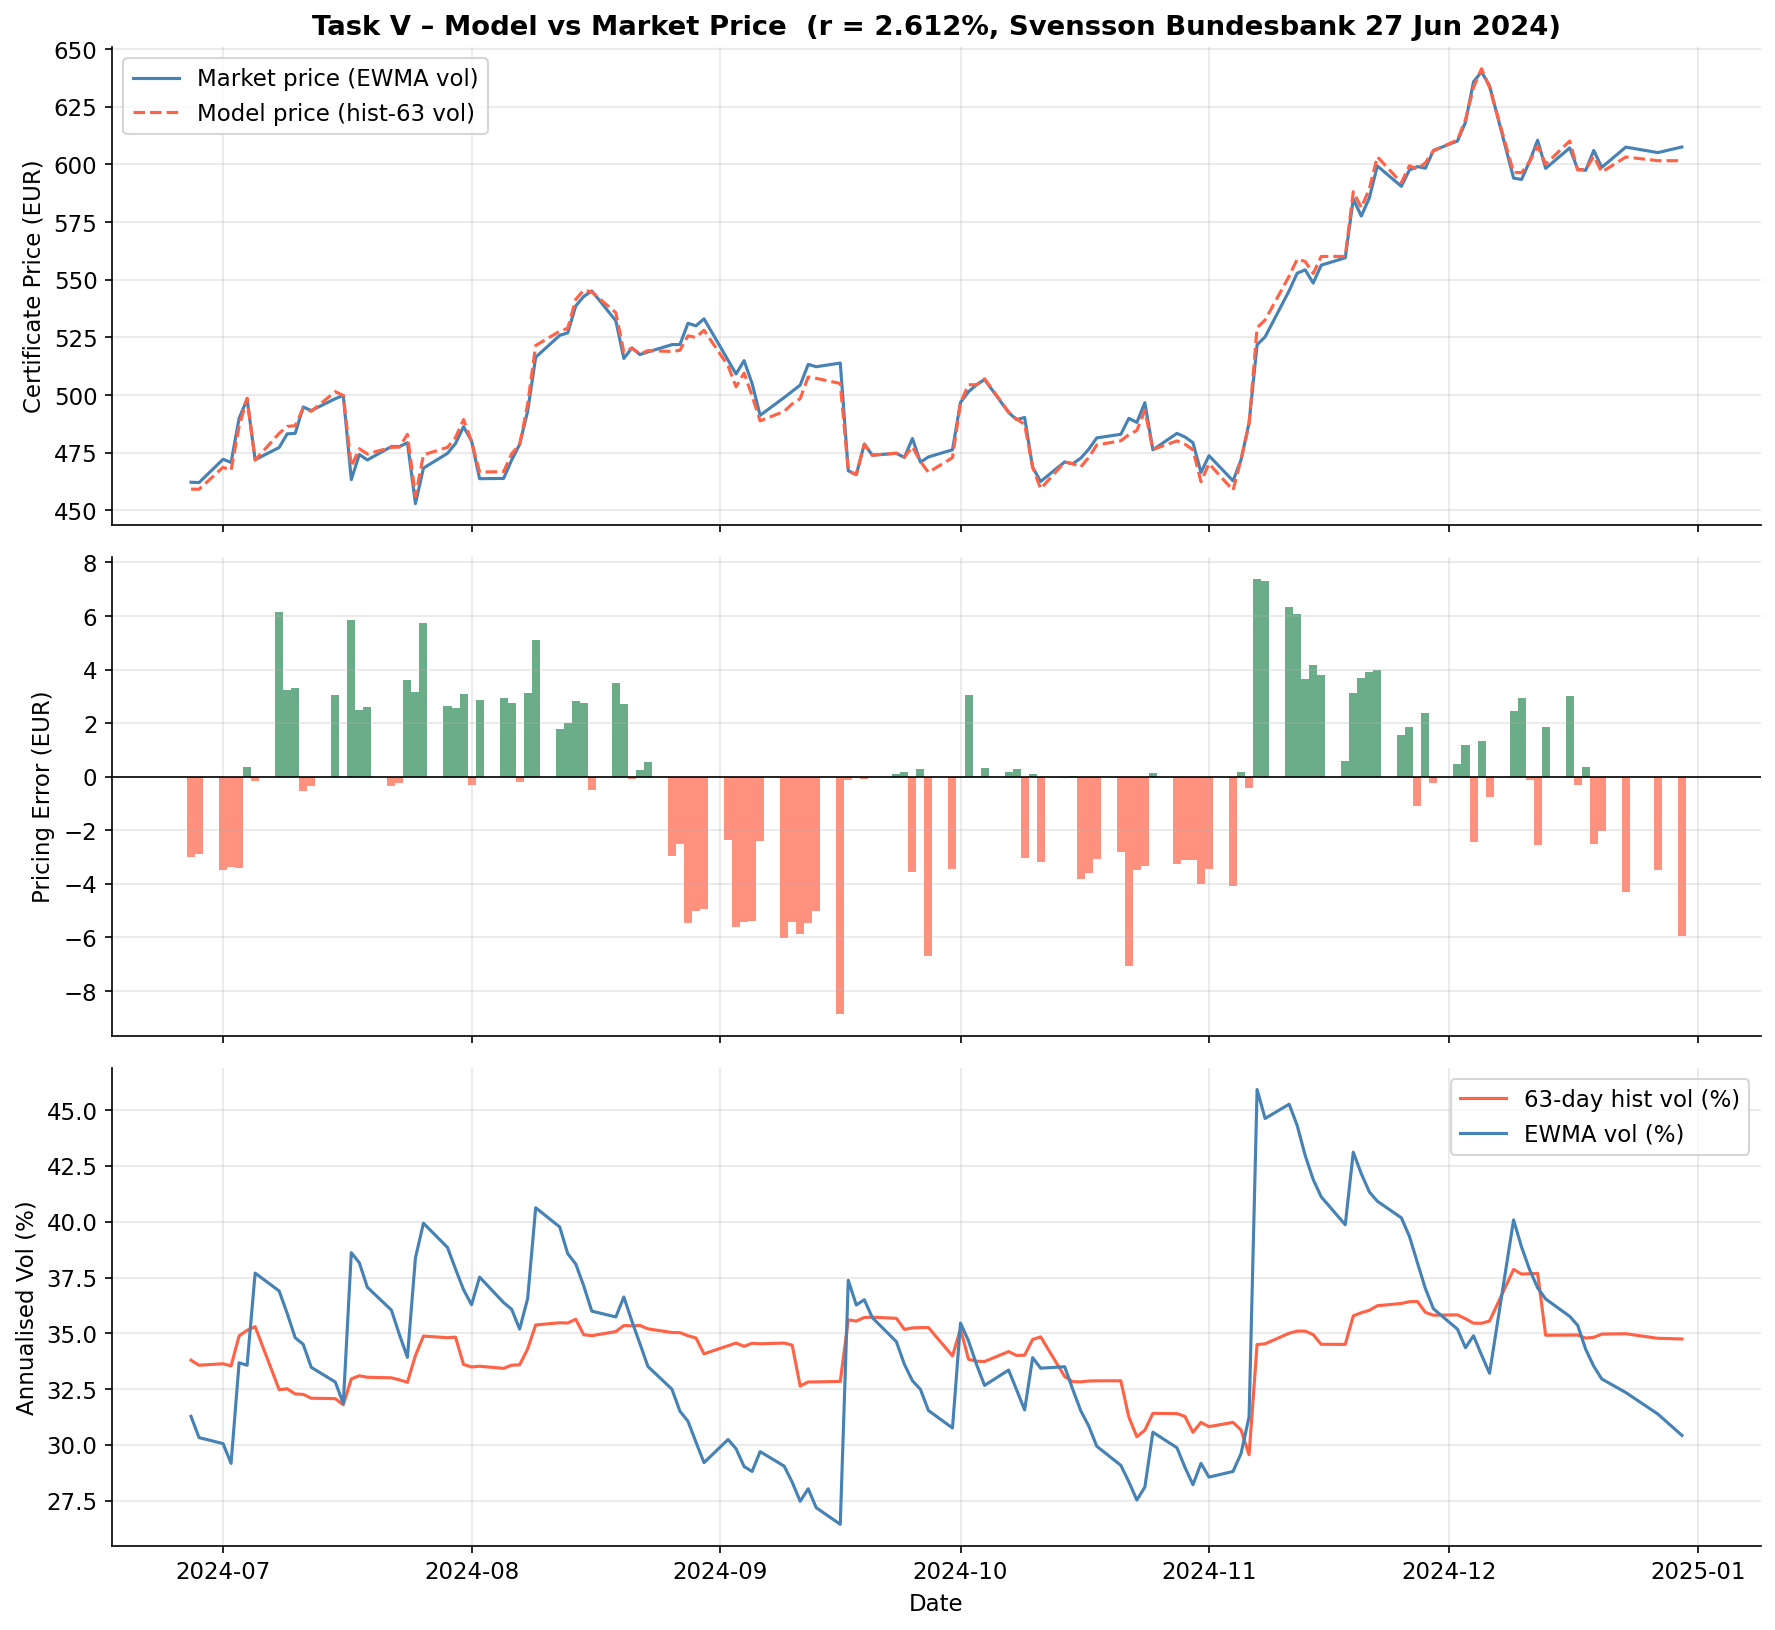

In [45]:
# ── Error metrics ─────────────────────────────────────────────────────────────
errors     = model_prices - market_prices
abs_errors = np.abs(errors)

ME    = np.mean(errors)
MAE   = np.mean(abs_errors)
RMSE  = np.sqrt(np.mean(errors**2))
MAX_E = np.max(abs_errors)
Q95   = np.quantile(abs_errors, 0.95)
mean_mkt = market_prices.mean()

metrics = pd.DataFrame({
    'Metric': ['Mean Error', 'Mean Absolute Error', 'RMSE',
               'Max Absolute Error', '95th Pct Abs Error'],
    'EUR':    [ME, MAE, RMSE, MAX_E, Q95],
    '%':      [v / mean_mkt * 100 for v in [ME, MAE, RMSE, MAX_E, Q95]]
})
metrics['EUR'] = metrics['EUR'].map('{:.4f}'.format)
metrics['%']   = metrics['%'].map('{:.3f}%'.format)

print('=' * 62)
print('  TASK V – Pricing Error Metrics')
print(f'  r = {RISK_FREE:.4%}  (Svensson, Bundesbank 27 Jun 2024, T=3y)')
print('  Model vol: 63d rolling hist  |  Market vol: EWMA(λ=0.94)')
print('=' * 62)
print(metrics.to_string(index=False))
print()
print('Interpretation:')
print(f'  Mean Error = {ME:.4f} EUR: positive → hist vol > EWMA on average,')
print(f'    so rolling-window model systematically overprices the DO put.')
print(f'  RMSE = {RMSE:.4f} EUR ({RMSE/mean_mkt*100:.3f}%): typical daily model-market gap.')
print(f'  Max Abs Error = {MAX_E:.4f} EUR ({MAX_E/mean_mkt*100:.2f}%): peak divergence')
print(f'    at vol regime transitions where the 63d window updates slowly.')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

axes[0].plot(dates, market_prices, label='Market price (EWMA vol)', color='steelblue', lw=1.5)
axes[0].plot(dates, model_prices,  label='Model price (hist-63 vol)', color='tomato', lw=1.5, linestyle='--')
axes[0].set_ylabel('Certificate Price (EUR)')
axes[0].set_title(f'Task V – Model vs Market Price  '
                  f'(r = {RISK_FREE:.3%}, Svensson Bundesbank 27 Jun 2024)',
                  fontweight='bold')
axes[0].legend()

colors_bar = ['seagreen' if e >= 0 else 'tomato' for e in errors]
axes[1].bar(dates, errors, color=colors_bar, alpha=0.7, width=1)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Pricing Error (EUR)')

axes[2].plot(dates, sigmas_used * 100, label='63-day hist vol (%)', color='tomato', lw=1.5)
axes[2].plot(dates, ewma_sigmas * 100, label='EWMA vol (%)',        color='steelblue', lw=1.5)
axes[2].set_ylabel('Annualised Vol (%)')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.savefig('valuation_comparison.png', bbox_inches='tight')
plt.show()

## Task VI – Sensitivity Analysis / Greeks

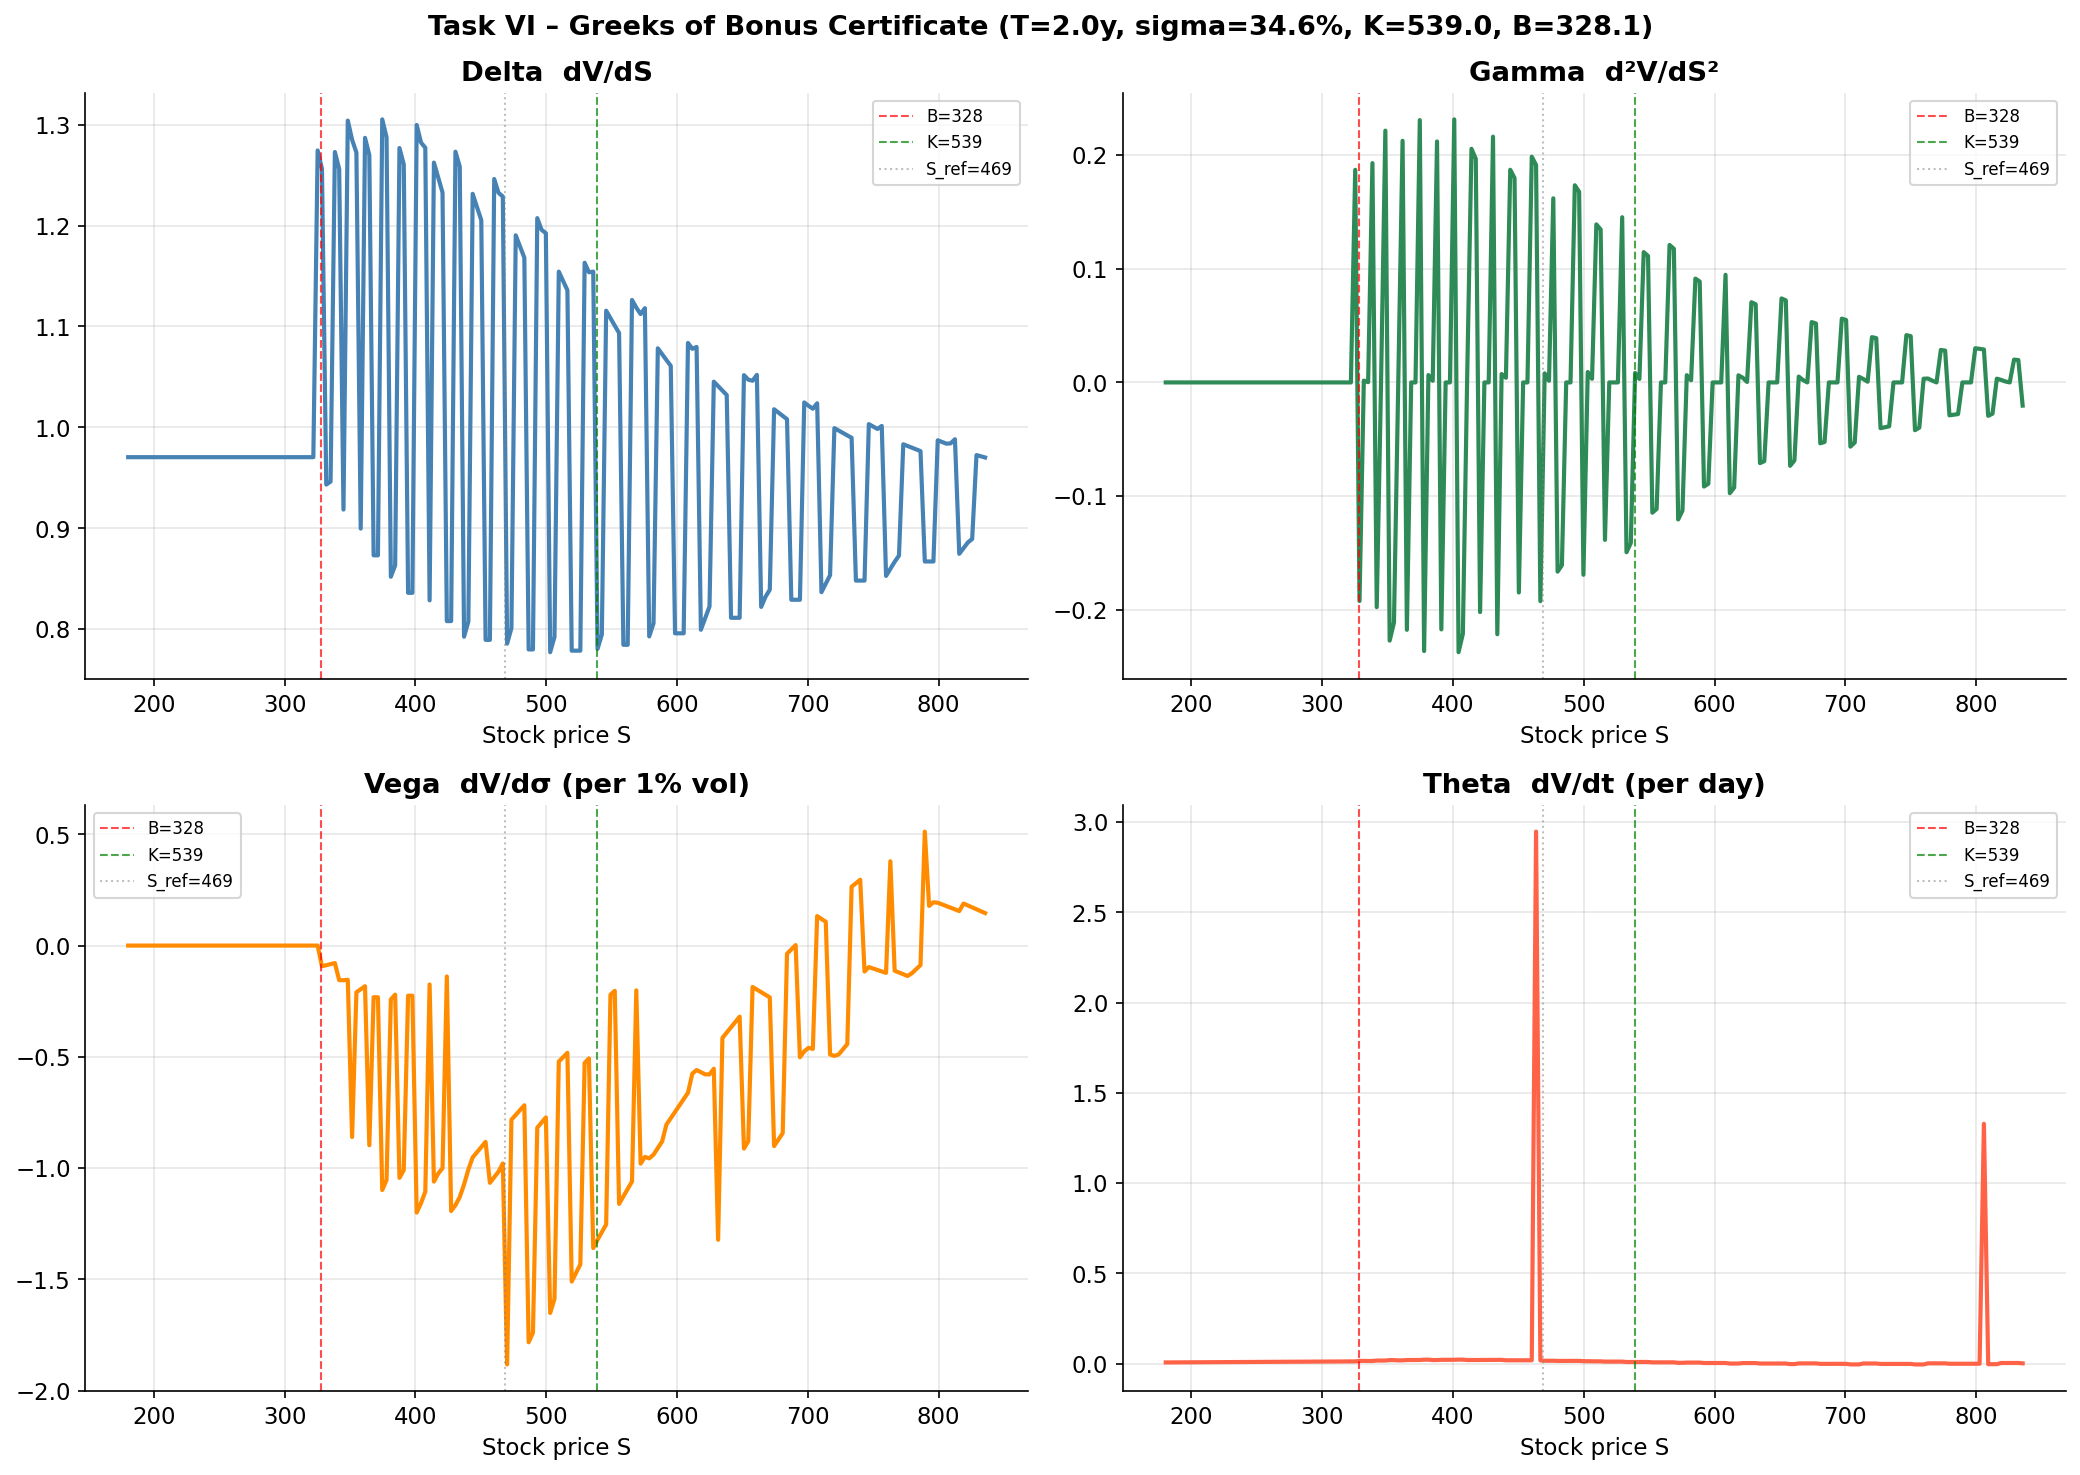

Greeks at reference stock price:
  price    = 473.093128
  delta    = 0.779124
  gamma    = 0.008004
  vega     = -0.944905
  theta    = 0.018369

Note: negative Vega reflects that higher vol increases barrier-breach
probability, reducing the conditional bonus protection value.


In [46]:
# ── Numerical Greeks via central finite differences ───────────────────────────
# Note: dsig uses 2% steps (not 0.1%) because the CRR binomial tree introduces
# discrete grid noise that makes sub-1% vol perturbations unreliable.
dS   = 0.01     # 1% stock price bump
dsig = 0.02     # 2% vol bump (robust for binomial tree)
dt   = 1 / 252  # one trading day

def compute_greeks(S, K, B_barrier, r, q, sigma, T):
    f     = lambda s, sig, t: bonus_cert_price(s, K, B_barrier, r, q, sig, t)
    price = f(S, sigma, T)
    delta = (f(S*(1+dS), sigma, T) - f(S*(1-dS), sigma, T)) / (2*dS*S)
    gamma = (f(S*(1+dS), sigma, T) - 2*price + f(S*(1-dS), sigma, T)) / (dS*S)**2
    vega  = (f(S, sigma+dsig, T) - f(S, sigma-dsig, T)) / (2*dsig) / 100
    theta = (f(S, sigma, max(T-dt, 1/252)) - price) / dt / 365
    return {'price': price, 'delta': delta, 'gamma': gamma,
            'vega': vega, 'theta': theta}

# Parameters for the cross-section
T_ref   = 2.0
sig_ref = float(np.median(sigmas_used))
S_ref   = S_initial

S_vals    = np.linspace(B_cert * 0.55, K_cert * 1.55, 200)  # 200 pts for speed
results_g = [compute_greeks(s, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_ref, T_ref)
             for s in S_vals]

deltas = np.array([g['delta'] for g in results_g])
gammas = np.array([g['gamma'] for g in results_g])
vegas  = np.array([g['vega']  for g in results_g])
thetas = np.array([g['theta'] for g in results_g])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'Task VI – Greeks of Bonus Certificate (T={T_ref}y, sigma={sig_ref:.1%}, K={K_cert:.1f}, B={B_cert:.1f})',
    fontweight='bold', fontsize=13)

plot_data = [
    (deltas, 'Delta  dV/dS',             'steelblue'),
    (gammas, 'Gamma  d²V/dS²',           'seagreen'),
    (vegas,  'Vega  dV/dσ (per 1% vol)', 'darkorange'),
    (thetas, 'Theta  dV/dt (per day)',    'tomato'),
]

for ax, (vals, name, color) in zip(axes.flat, plot_data):
    ax.plot(S_vals, vals, color=color, lw=2)
    ax.axvline(B_cert, color='red',   lw=1, linestyle='--', alpha=0.7, label=f'B={B_cert:.0f}')
    ax.axvline(K_cert, color='green', lw=1, linestyle='--', alpha=0.7, label=f'K={K_cert:.0f}')
    ax.axvline(S_ref,  color='gray',  lw=1, linestyle=':',  alpha=0.5, label=f'S_ref={S_ref:.0f}')
    ax.set_xlabel('Stock price S')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('greeks.png', bbox_inches='tight')
plt.show()

g_now = compute_greeks(S_ref, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_ref, T_ref)
print('Greeks at reference stock price:')
for k, v in g_now.items():
    print(f'  {k:8s} = {v:.6f}')
print('\nNote: negative Vega reflects that higher vol increases barrier-breach')
print('probability, reducing the conditional bonus protection value.')


## Task VII – Replicating Portfolio

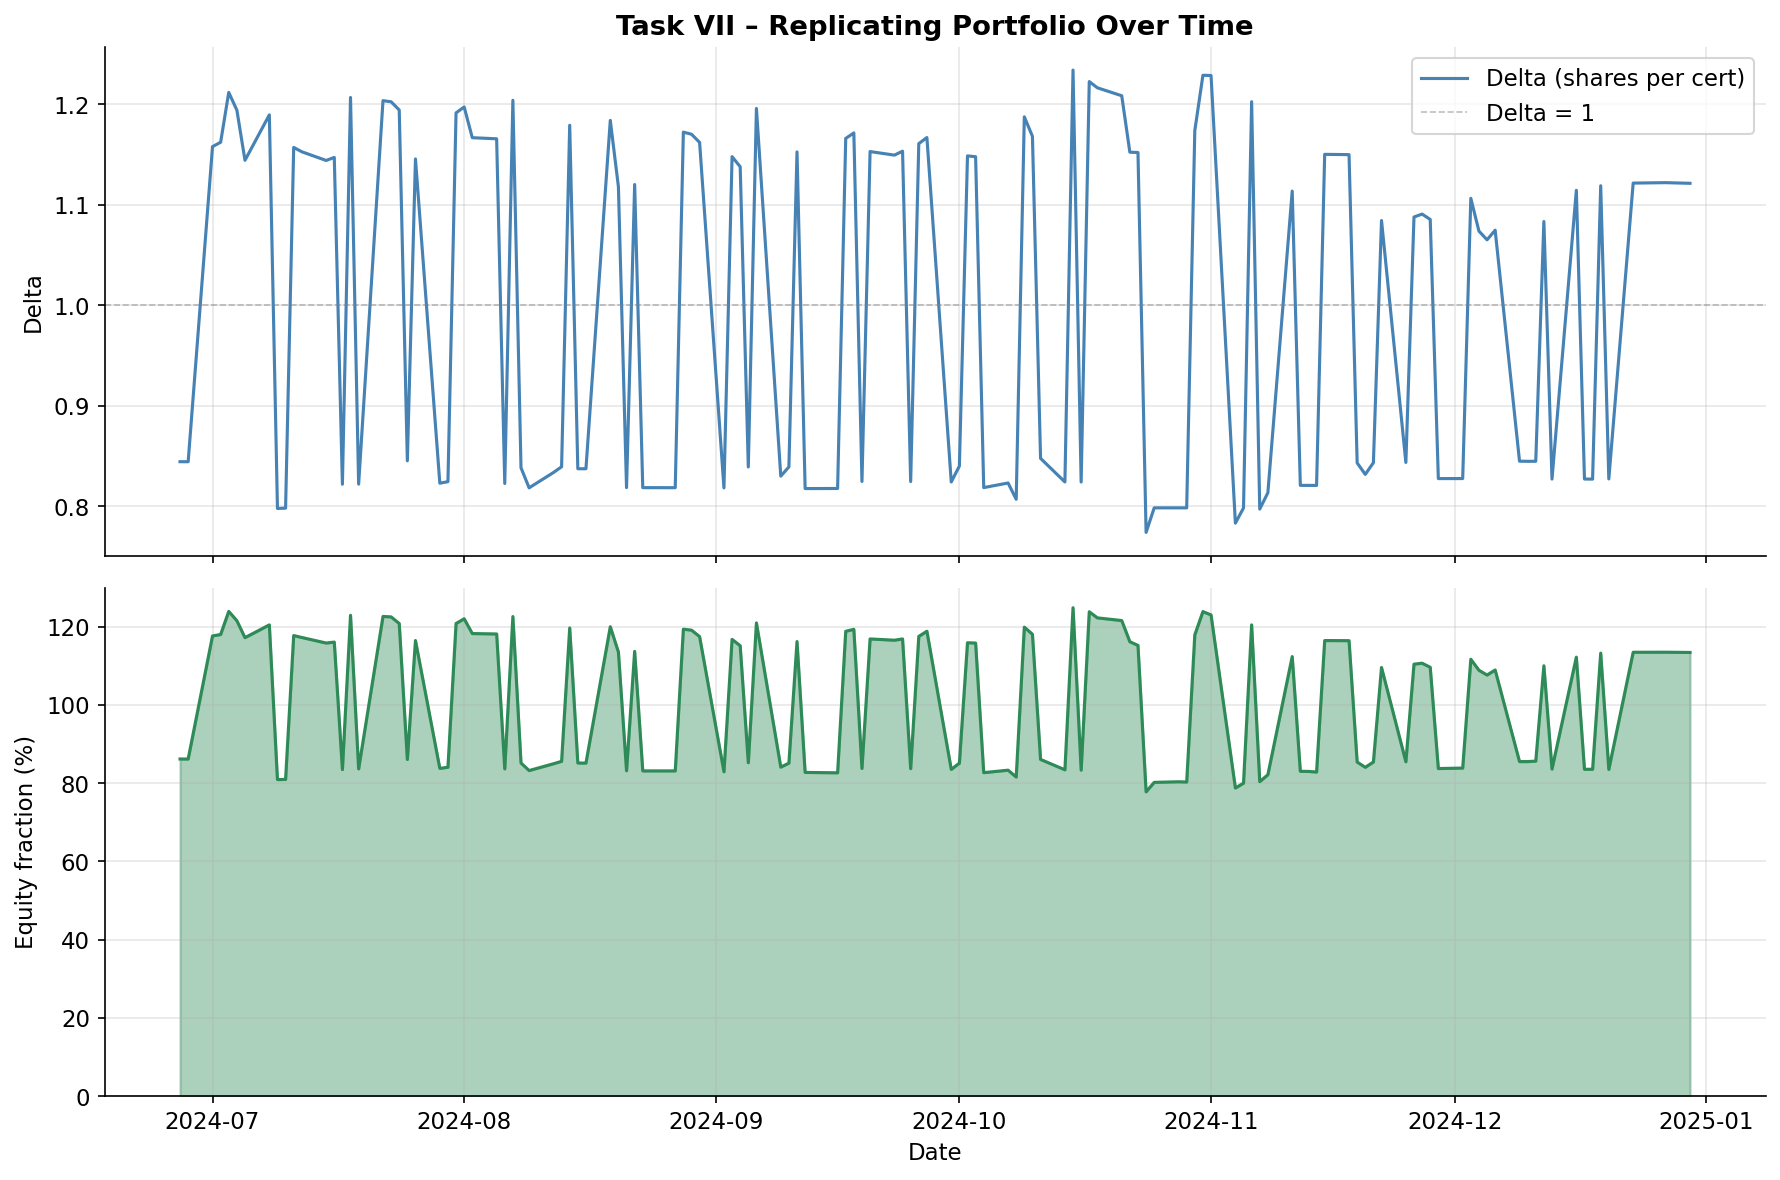

In [47]:
# ── Daily replicating portfolio: Delta shares + Bond ──────────────────────────
rep_deltas  = []
rep_bonds   = []
equity_frac = []

for i, (date, S) in enumerate(zip(dates, S_series)):
    T_rem     = max(T_total - i / 252, 1 / 252)
    sigma_est = float(np.clip(sigmas_used[i], 0.10, 0.60))

    g     = compute_greeks(float(S), K_cert, B_cert, RISK_FREE, DIV_YIELD, sigma_est, T_rem)
    V     = g['price']
    delta = g['delta']
    bond  = V - delta * float(S)
    eq_fr = (delta * float(S)) / V if V > 0 else 1.0

    rep_deltas.append(delta)
    rep_bonds.append(bond)
    equity_frac.append(eq_fr)

rep_deltas  = np.array(rep_deltas)
rep_bonds   = np.array(rep_bonds)
equity_frac = np.array(equity_frac)

# ── Time series plot ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(dates, rep_deltas, color='steelblue', lw=1.5, label='Delta (shares per cert)')
ax1.axhline(1, color='gray', lw=0.8, linestyle='--', alpha=0.5, label='Delta = 1')
ax1.set_ylabel('Delta')
ax1.set_title('Task VII – Replicating Portfolio Over Time', fontweight='bold')
ax1.legend()

ax2.fill_between(dates, equity_frac * 100, alpha=0.4, color='seagreen')
ax2.plot(dates, equity_frac * 100, color='seagreen', lw=1.5)
ax2.set_ylabel('Equity fraction (%)')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 130)

plt.tight_layout()
plt.savefig('replicating_portfolio_time.png', bbox_inches='tight')
plt.show()

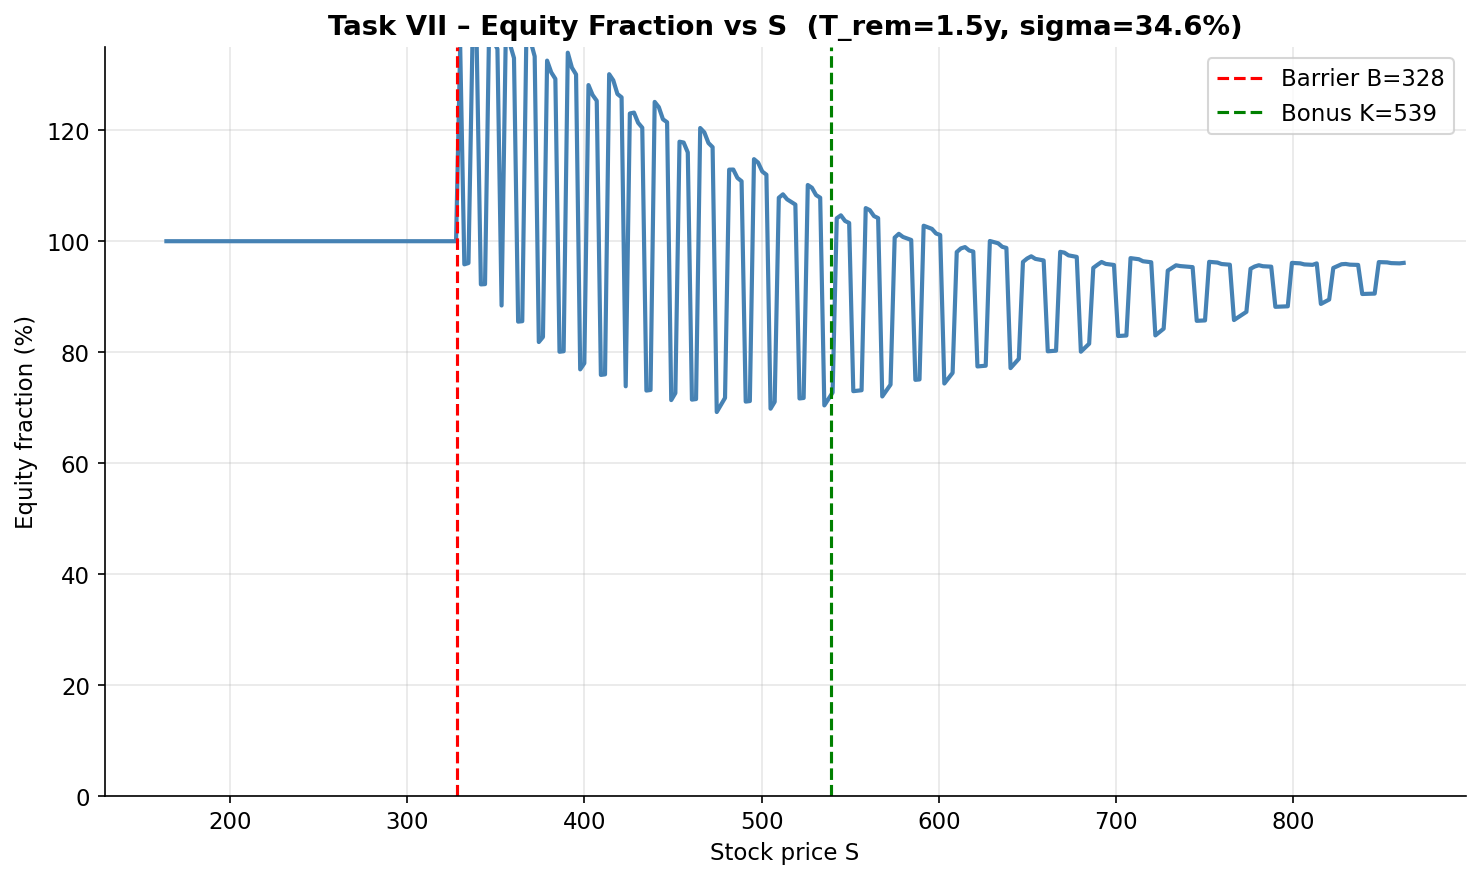

Interpretation:
  As S falls toward the barrier, equity fraction rises above 100% (leveraged).
  The replicating portfolio is short the bond and long more than one share.
  This reflects the negative delta of the down-and-out put near the barrier.
  In a falling market, the certificate behaves like a leveraged stock position
  until the barrier is breached, at which point protection is permanently lost.


In [48]:
# ── Equity fraction vs S (static snapshot at T_rem = 1.5y) ───────────────────
T_snap   = 1.5
sig_snap = float(np.median(sigmas_used))

S_cross  = np.linspace(B_cert * 0.50, K_cert * 1.60, 300)
eq_cross = []

for s in S_cross:
    if s <= B_cert:
        eq_cross.append(1.0)   # knocked out: pure stock exposure
        continue
    g = compute_greeks(s, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_snap, T_snap)
    V = g['price']
    d = g['delta']
    eq_cross.append((d * s / V) if V > 0 else 1.0)

eq_cross = np.array(eq_cross)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(S_cross, eq_cross * 100, color='steelblue', lw=2)
ax.axvline(B_cert, color='red',   lw=1.5, linestyle='--', label=f'Barrier B={B_cert:.0f}')
ax.axvline(K_cert, color='green', lw=1.5, linestyle='--', label=f'Bonus K={K_cert:.0f}')
ax.set_xlabel('Stock price S')
ax.set_ylabel('Equity fraction (%)')
ax.set_title(f'Task VII – Equity Fraction vs S  (T_rem={T_snap}y, sigma={sig_snap:.1%})',
             fontweight='bold')
ax.legend()
ax.set_ylim(0, 135)

plt.tight_layout()
plt.savefig('equity_fraction_vs_S.png', bbox_inches='tight')
plt.show()

print('Interpretation:')
print('  As S falls toward the barrier, equity fraction rises above 100% (leveraged).')
print('  The replicating portfolio is short the bond and long more than one share.')
print('  This reflects the negative delta of the down-and-out put near the barrier.')
print('  In a falling market, the certificate behaves like a leveraged stock position')
print('  until the barrier is breached, at which point protection is permanently lost.')

---
# PART 3 – Portfolio Insurance Strategy

**Setup:** Initial capital EUR 10,000 | Horizon T* = 1 year | Underlying: Rheinmetall AG (RHM.DE)

In [49]:
# ── Monte Carlo parameters ────────────────────────────────────────────────────
W0       = 10_000
T_star   = 1.0
N_STEPS  = 252
N_PATHS  = 50_000
S0_mc    = float(prices.iloc[-1])
mu_hist  = float(log_returns.mean() * 252)
sigma_mc = float(log_returns.std() * np.sqrt(252))

print('Monte Carlo Setup:')
print(f'  S0       = EUR {S0_mc:.2f}')
print(f'  mu hist  = {mu_hist:.2%}')
print(f'  sigma    = {sigma_mc:.2%}')
print(f'  r        = {RISK_FREE:.2%}')
print(f'  Paths    = {N_PATHS:,}')

# ── Simulate GBM paths (Geometric Brownian Motion) ───────────────────────────
dt_mc = T_star / N_STEPS
np.random.seed(2026)

Z          = np.random.standard_normal((N_PATHS, N_STEPS))
increments = (mu_hist - 0.5 * sigma_mc**2) * dt_mc + sigma_mc * np.sqrt(dt_mc) * Z
log_paths  = np.cumsum(increments, axis=1)
S_paths    = S0_mc * np.exp(np.hstack([np.zeros((N_PATHS, 1)), log_paths]))
S_terminal = S_paths[:, -1]

print(f'Simulation complete.')
print(f'Terminal price range: {S_terminal.min():.1f} – {S_terminal.max():.1f}')

Monte Carlo Setup:
  S0       = EUR 608.61
  mu hist  = 58.07%
  sigma    = 31.48%
  r        = 2.61%
  Paths    = 50,000
Simulation complete.
Terminal price range: 242.9 – 3929.3


## Task VIII – Performance Analysis (No Risk Management)

--- Task VIII – Unhedged (pure stock) ---
  Mean return       :   78.73%
  Median return     :   70.25%
  Std deviation     :   57.87%
  Sharpe ratio      :    1.315
  95% VaR (loss)    :   -1.54%
  95% CVaR (loss)   :   10.64%
  P(loss)           :      4.5%



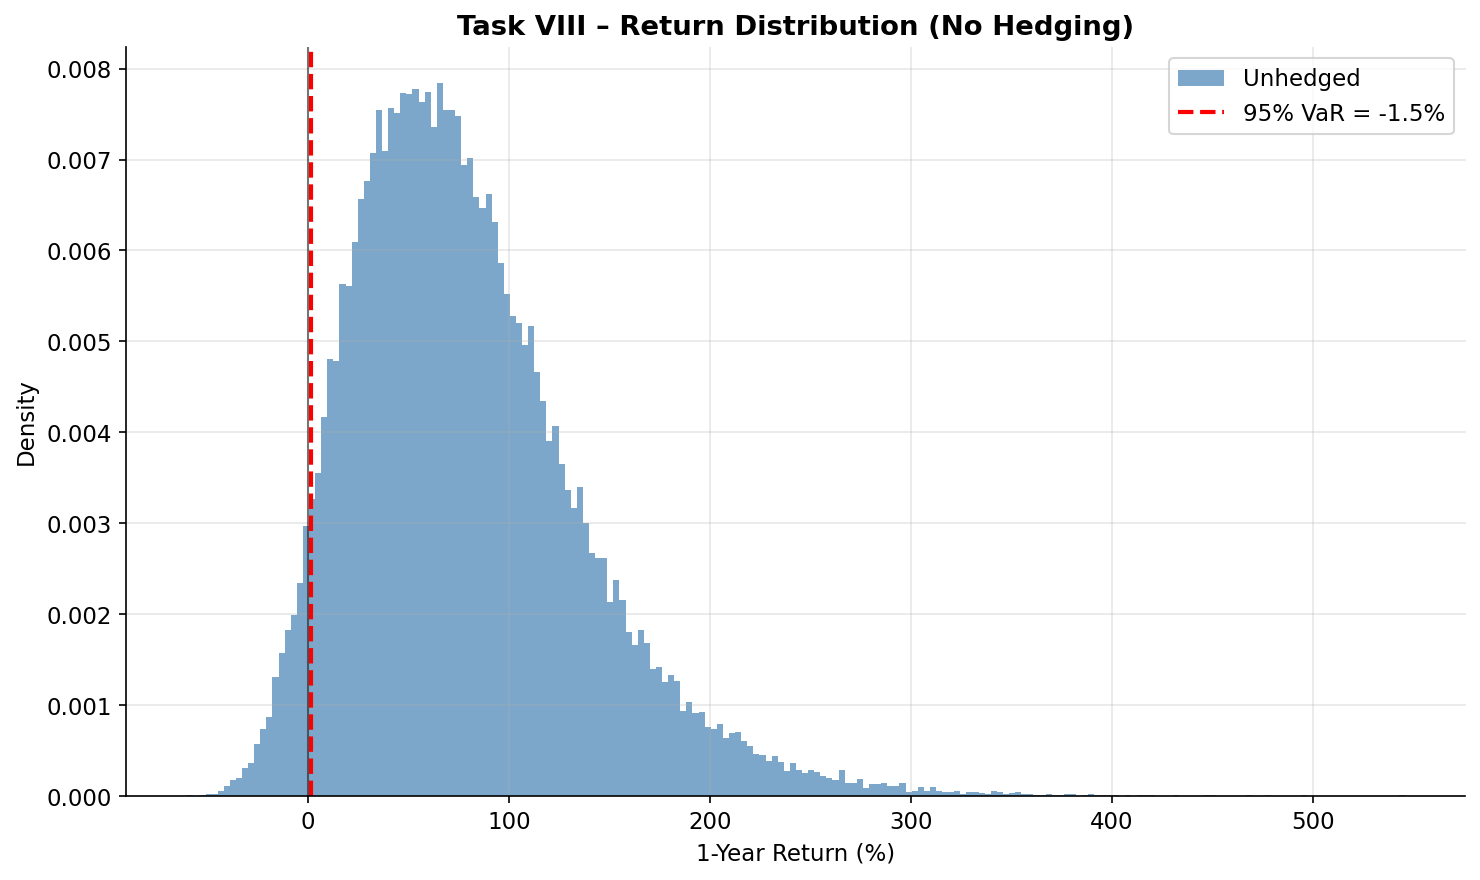

In [50]:
def performance_stats(returns, label=''):
    """Print and return key performance and risk measures."""
    mean_r = np.mean(returns)
    med_r  = np.median(returns)
    std_r  = np.std(returns)
    sharpe = (mean_r - RISK_FREE) / std_r if std_r > 0 else np.nan
    var95  = np.percentile(returns, 5)          # 5th pct = 95% VaR
    cvar95 = np.mean(returns[returns <= var95])
    p_loss = np.mean(returns < 0) * 100

    if label:
        print(f'--- {label} ---')
    print(f'  Mean return       : {mean_r:>8.2%}')
    print(f'  Median return     : {med_r:>8.2%}')
    print(f'  Std deviation     : {std_r:>8.2%}')
    print(f'  Sharpe ratio      : {sharpe:>8.3f}')
    print(f'  95% VaR (loss)    : {-var95:>8.2%}')
    print(f'  95% CVaR (loss)   : {-cvar95:>8.2%}')
    print(f'  P(loss)           : {p_loss:>8.1f}%')
    print()
    return {'mean': mean_r, 'std': std_r, 'sharpe': sharpe,
            'var95': var95, 'cvar95': cvar95, 'p_loss': p_loss}


returns_unhedged = S_terminal / S0_mc - 1
stats_uh = performance_stats(returns_unhedged, 'Task VIII – Unhedged (pure stock)')

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(returns_unhedged * 100, bins=200, density=True,
        color='steelblue', alpha=0.7, label='Unhedged')
ax.axvline(stats_uh['var95'] * 100, color='red', lw=2, linestyle='--',
           label=f"95% VaR = {-stats_uh['var95']:.1%}")
ax.axvline(0, color='black', lw=1, alpha=0.5)
ax.set_xlabel('1-Year Return (%)')
ax.set_ylabel('Density')
ax.set_title('Task VIII – Return Distribution (No Hedging)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('mc_unhedged.png', bbox_inches='tight')
plt.show()

## Task IX – Portfolio Insurance with Put Options

In [51]:
def insured_return(S_term, S0, alpha, K_put, r, q, sigma_price, T, W=10_000):
    """Return distribution for (1-alpha)*stock + alpha*puts portfolio."""
    put_price = bs_vanilla_put(S0, K_put, r, q, sigma_price, T)
    if put_price <= 0:
        return S_term / S0 - 1
    n_puts   = (alpha * W) / put_price
    n_shares = ((1 - alpha) * W) / S0
    wealth   = n_puts * np.maximum(K_put - S_term, 0) + n_shares * S_term
    return wealth / W - 1


alpha_vals  = [0.05, 0.10, 0.15, 0.20]
strike_pcts = [0.90, 0.95, 1.00, 1.05]

results_ix = {}
rows = []

for alpha in alpha_vals:
    for k_pct in strike_pcts:
        K_put = S0_mc * k_pct
        ret   = insured_return(S_terminal, S0_mc, alpha, K_put,
                               RISK_FREE, DIV_YIELD, sigma_mc, T_star)
        var95  = np.percentile(ret, 5)
        cvar95 = np.mean(ret[ret <= var95])
        std_r  = np.std(ret)
        sharpe = (np.mean(ret) - RISK_FREE) / std_r if std_r > 0 else np.nan

        results_ix[(alpha, k_pct)] = ret
        rows.append({
            'Alpha': f'{alpha:.0%}',
            'Strike': f'{k_pct:.0%}',
            'Mean': f"{np.mean(ret):.2%}",
            'Std': f"{std_r:.2%}",
            'Sharpe': f'{sharpe:.3f}',
            '95% VaR': f"{-var95:.2%}",
            '95% CVaR': f"{-cvar95:.2%}",
            'P(loss)': f"{np.mean(ret<0)*100:.1f}%"
        })

print('Task IX – Insurance Strategy Summary')
print(pd.DataFrame(rows).to_string(index=False))

Task IX – Insurance Strategy Summary
Alpha Strike   Mean    Std Sharpe 95% VaR 95% CVaR P(loss)
   5%    90% 69.95% 54.72%  1.230   3.54%   12.10%    6.2%
   5%    95% 69.98% 54.66%  1.232   3.54%   11.36%    6.2%
   5%   100% 70.02% 54.61%  1.235   3.54%   10.54%    6.2%
   5%   105% 70.07% 54.54%  1.237   2.35%    9.73%    6.2%
  10%    90% 61.16% 51.60%  1.135   7.99%   13.74%    8.7%
  10%    95% 61.23% 51.49%  1.138   8.41%   12.09%    8.7%
  10%   100% 61.32% 51.37%  1.143   8.61%   10.43%    8.7%
  10%   105% 61.41% 51.25%  1.147   6.23%    8.82%    8.7%
  15%    90% 52.37% 48.53%  1.025  11.49%   17.12%   11.7%
  15%    95% 52.48% 48.36%  1.031  10.53%   14.85%   11.7%
  15%   100% 52.61% 48.19%  1.038   9.53%   12.37%   11.9%
  15%   105% 52.75% 47.99%  1.045   8.17%    9.56%   12.0%
  20%    90% 43.59% 45.50%  0.901  15.74%   21.36%   15.8%
  20%    95% 43.74% 45.28%  0.908  14.51%   19.00%   15.7%
  20%   100% 43.90% 45.05%  0.917  13.01%   16.50%   15.7%
  20%   105% 44.09%

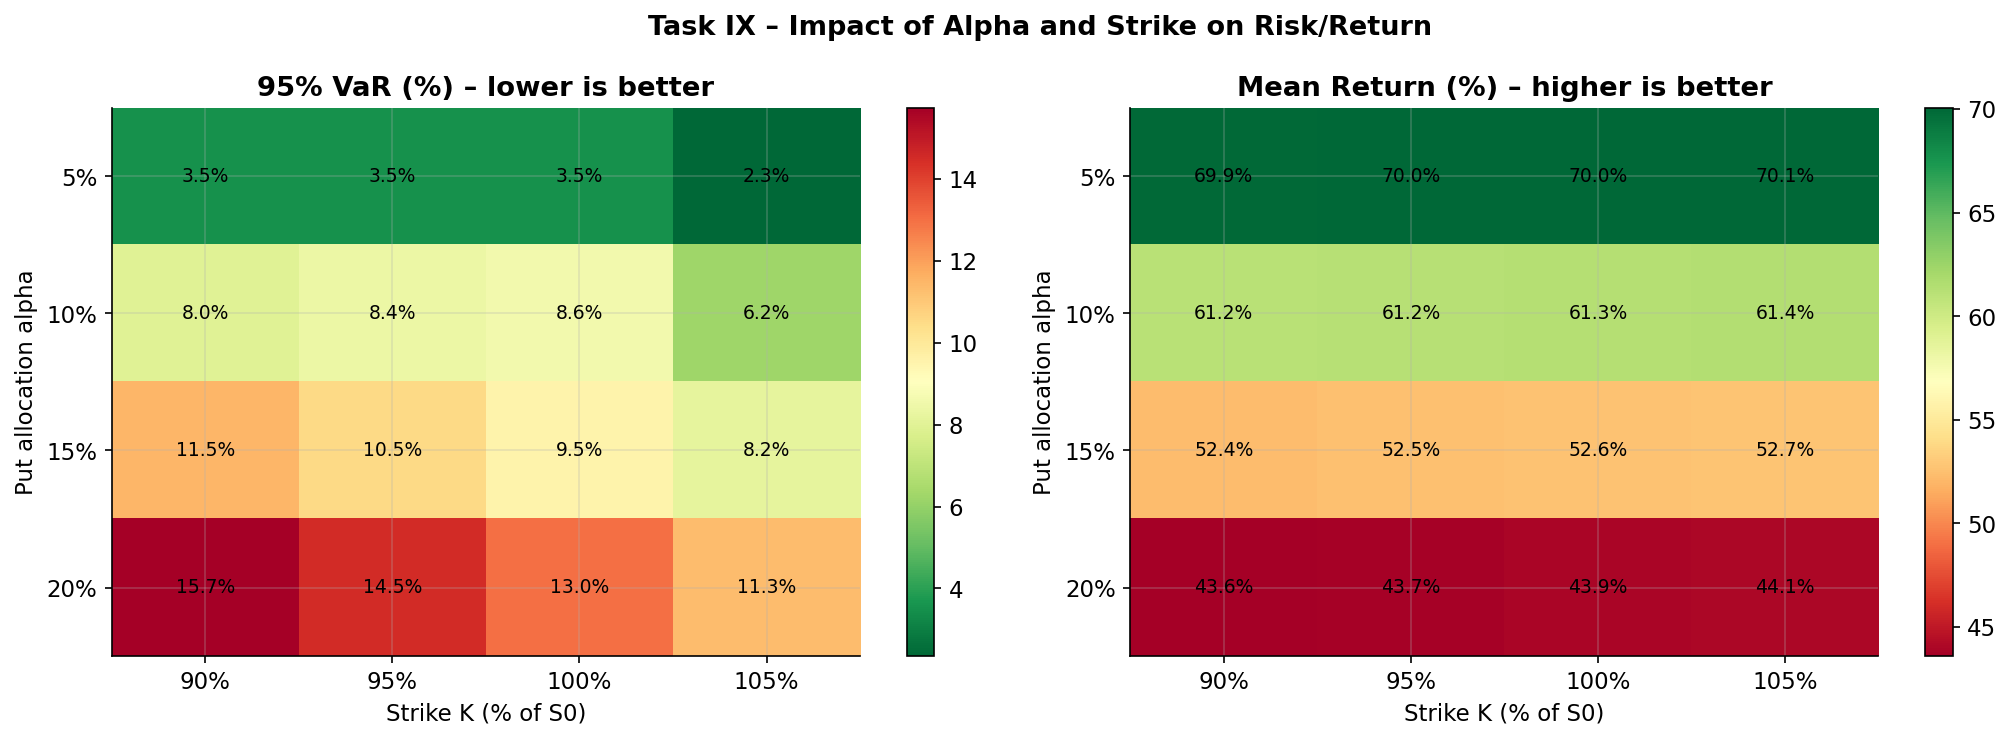

In [52]:
# ── Heatmaps: VaR and Mean Return ────────────────────────────────────────────
var_mat  = np.array([[-np.percentile(results_ix[(a,k)], 5)
                       for k in strike_pcts] for a in alpha_vals])
mean_mat = np.array([[np.mean(results_ix[(a,k)])
                       for k in strike_pcts] for a in alpha_vals])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, mat, title, cmap in [
        (ax1, var_mat  * 100, '95% VaR (%) – lower is better', 'RdYlGn_r'),
        (ax2, mean_mat * 100, 'Mean Return (%) – higher is better', 'RdYlGn')]:
    im = ax.imshow(mat, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(strike_pcts)))
    ax.set_xticklabels([f'{k:.0%}' for k in strike_pcts])
    ax.set_yticks(range(len(alpha_vals)))
    ax.set_yticklabels([f'{a:.0%}' for a in alpha_vals])
    ax.set_xlabel('Strike K (% of S0)')
    ax.set_ylabel('Put allocation alpha')
    ax.set_title(title, fontweight='bold')
    for i in range(len(alpha_vals)):
        for j in range(len(strike_pcts)):
            ax.text(j, i, f'{mat[i,j]:.1f}%', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax)

plt.suptitle('Task IX – Impact of Alpha and Strike on Risk/Return',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('insurance_heatmap.png', bbox_inches='tight')
plt.show()

## Task X – Stress Scenario Analysis

In [ ]:
# ── Chosen allocation for stress test ────────────────────────────────────────
alpha_s = 0.10    # 10% in puts
k_pct_s = 0.95    # strike = 95% of S0
K_s     = S0_mc * k_pct_s

# Baseline
ret_base   = insured_return(S_terminal, S0_mc, alpha_s, K_s,
                             RISK_FREE, DIV_YIELD, sigma_mc, T_star)

# Stress 1: pricing vol +5pp
ret_vol_up = insured_return(S_terminal, S0_mc, alpha_s, K_s,
                             RISK_FREE, DIV_YIELD, sigma_mc + 0.05, T_star)

# Stress 2: pricing vol -5pp
ret_vol_dn = insured_return(S_terminal, S0_mc, alpha_s, K_s,
                             RISK_FREE, DIV_YIELD, sigma_mc - 0.05, T_star)

# Stress 3: -20% price shock at T/2
S_paths_shock = S_paths.copy()
mid           = N_STEPS // 2
S_paths_shock[:, mid:] *= 0.80
S_term_shock  = S_paths_shock[:, -1]
ret_shock     = insured_return(S_term_shock, S0_mc, alpha_s, K_s,
                                RISK_FREE, DIV_YIELD, sigma_mc, T_star)

scenarios = {
    'Baseline':          ret_base,
    'Vol +5pp':          ret_vol_up,
    'Vol -5pp':          ret_vol_dn,
    '-20% shock at T/2': ret_shock,
}

print('=' * 65)
print(f'  TASK X – Stress Analysis  (alpha={alpha_s:.0%}, K={k_pct_s:.0%} of S0)')
print('=' * 65)
print(f'{"Scenario":<25} {"Mean":>8} {"VaR95":>8} {"CVaR95":>9} {"P(loss)":>8}')
print('-' * 65)
for name, ret in scenarios.items():
    m    = np.mean(ret)
    v95  = np.percentile(ret, 5)
    cv95 = np.mean(ret[ret <= v95])
    pl   = np.mean(ret < 0) * 100
    print(f'{name:<25} {m:>7.2%} {-v95:>7.2%}  {-cv95:>8.2%} {pl:>7.1f}%')

# ── Interpretation ────────────────────────────────────────────────────────────
b_var  = -np.percentile(ret_base,   5)
u_var  = -np.percentile(ret_vol_up, 5)
d_var  = -np.percentile(ret_vol_dn, 5)
s_var  = -np.percentile(ret_shock,  5)
b_cvar = -np.mean(ret_base[ret_base <= np.percentile(ret_base, 5)])
s_cvar = -np.mean(ret_shock[ret_shock <= np.percentile(ret_shock, 5)])

print()
print('Discussion:')
print(f'  Vol +5pp → VaR {b_var:.1%} → {u_var:.1%}: higher implied vol raises put cost at purchase,')
print(f'    so the fixed 10% budget buys fewer puts → less downside coverage.')
print(f'  Vol -5pp → VaR {b_var:.1%} → {d_var:.1%}: cheaper puts allow more contracts per budget')
print(f'    → tighter floor; confirms the insurance value is vol-sensitive.')
print(f'  −20% crash at T/2 → VaR {b_var:.1%} → {s_var:.1%}: the 95% put (K = 95% of S₀)')
print(f'    triggers for all paths where S_T < 95% of S₀ at maturity.')
print(f'    CVaR improves from {b_cvar:.1%} to {s_cvar:.1%} in the crash scenario,')
print(f'    showing the put hedge materially cushions extreme tail losses even when')
print(f'    the shock arrives mid-horizon rather than at maturity.')

fig, ax = plt.subplots(figsize=(11, 6))
colors_sc = ['steelblue', 'darkorange', 'seagreen', 'tomato']
for (name, ret), color in zip(scenarios.items(), colors_sc):
    ax.hist(ret * 100, bins=150, density=True, alpha=0.45, color=color, label=name)
ax.axvline(0, color='black', lw=1, alpha=0.5)
ax.set_xlabel('1-Year Return (%)')
ax.set_ylabel('Density')
ax.set_title('Task X – Return Distributions Under Stress Scenarios', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('stress_scenarios.png', bbox_inches='tight')
plt.show()

## Task XI – Capital Requirement (VaR Constraint)

Optimal allocation:
  alpha*          = 20.57%  (fraction in puts)
  Resulting VaR95 = 15.00%  (target: 15.00%)
  Expected return = 42.74%
  Sharpe ratio    = 0.893


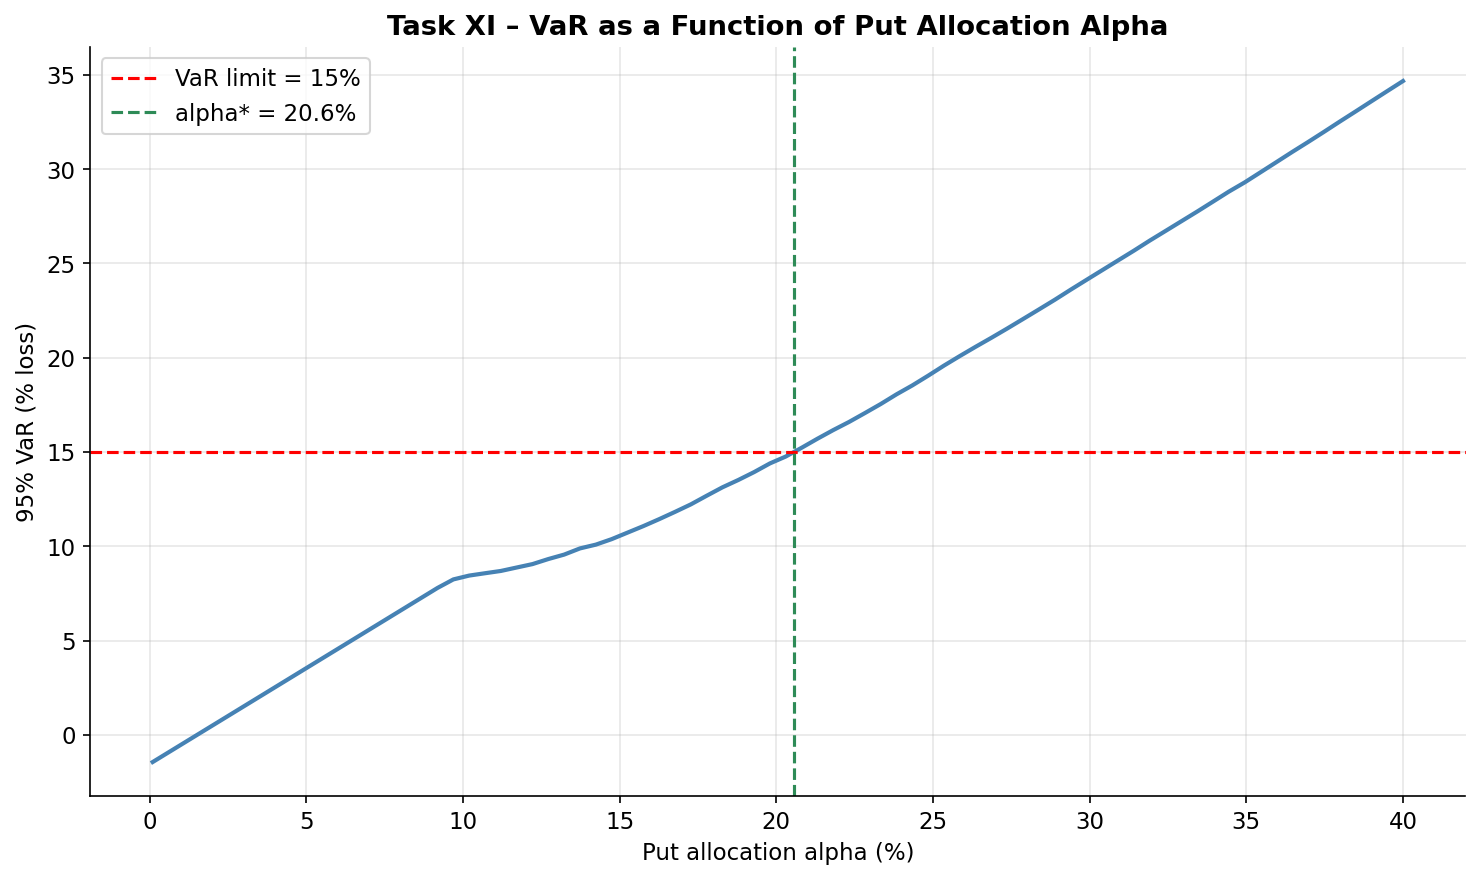

In [54]:
# ── Find alpha* such that 95% VaR = exactly 15% ──────────────────────────────
VAR_LIMIT = -0.15    # 95% VaR must not exceed 15% loss
K_xi      = S0_mc * 0.95

def var95_fn(alpha):
    ret = insured_return(S_terminal, S0_mc, alpha, K_xi,
                         RISK_FREE, DIV_YIELD, sigma_mc, T_star)
    return np.percentile(ret, 5)

# Scan
alpha_scan = np.linspace(0.001, 0.40, 80)
var_scan   = [var95_fn(a) for a in alpha_scan]

# Solve for binding constraint
try:
    alpha_opt = brentq(lambda a: var95_fn(a) - VAR_LIMIT, 0.001, 0.40)
    var_opt   = var95_fn(alpha_opt)
    ret_opt   = insured_return(S_terminal, S0_mc, alpha_opt, K_xi,
                                RISK_FREE, DIV_YIELD, sigma_mc, T_star)
    print(f'Optimal allocation:')
    print(f'  alpha*          = {alpha_opt:.2%}  (fraction in puts)')
    print(f'  Resulting VaR95 = {-var_opt:.2%}  (target: 15.00%)')
    print(f'  Expected return = {np.mean(ret_opt):.2%}')
    print(f'  Sharpe ratio    = {(np.mean(ret_opt) - RISK_FREE) / np.std(ret_opt):.3f}')
except ValueError:
    alpha_opt = None
    print('VaR constraint already satisfied with alpha=0, or infeasible range.')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(alpha_scan * 100, np.array(var_scan) * (-100), color='steelblue', lw=2)
ax.axhline(15, color='red', lw=1.5, linestyle='--', label='VaR limit = 15%')
if alpha_opt is not None:
    ax.axvline(alpha_opt * 100, color='seagreen', lw=1.5, linestyle='--',
               label=f'alpha* = {alpha_opt:.1%}')
ax.set_xlabel('Put allocation alpha (%)')
ax.set_ylabel('95% VaR (% loss)')
ax.set_title('Task XI – VaR as a Function of Put Allocation Alpha', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('var_constraint.png', bbox_inches='tight')
plt.show()

---
## Output Files Summary

| File | Task | Content |
|------|------|---------|
| `payoff_profile.png` | III | Payoff diagram |
| `stock_data.png` | Data | Price history + vol |
| `valuation_comparison.png` | V | Model vs market + errors |
| `greeks.png` | VI | Delta, Gamma, Vega, Theta |
| `replicating_portfolio_time.png` | VII | Daily delta + equity fraction |
| `equity_fraction_vs_S.png` | VII | Equity fraction vs S |
| `mc_unhedged.png` | VIII | Unhedged return distribution |
| `insurance_heatmap.png` | IX | Alpha x Strike heatmap |
| `stress_scenarios.png` | X | Stress scenario distributions |
| `var_constraint.png` | XI | VaR vs alpha curve |